# Circuit Analysis with Python
Last update: 5 Sept 2026

<!--
-->

- rewrite to make the focus about Python, JupyterLab and not so much on the circuits themselves, describe how Python is used to analyize the circuits, both numerically and symbollically.
  - what is the value of symbolic solutions?
- ~need to consolidate all the LTSpice schematics in one directory, see `/home/jeff32/Documents/Solving Electrical Engineering Problems with Python Blog/python circuits/Circuit_analysis_with_python_paper/`~
  - ~rename files~
- clean up and finish examples
  - ~remove bridge t-circuit example.~
  - ~finish initial conditions~
  - update and finalize the narrative
  - export to MD to see if Typst MD comes through
  - spell and grammar check
  - ~remove unused figures~
- copy text, equations, tables and figures to typst
- post to GitHub and link to in paper.
  - ~make some place holders, `Circuit_Analysis_with_Python`, sub folders for LTSpice files, plots, Typst source files, ...~  
- ~add save command to plots.~
- publish
  - [About TechRxiv](https://www.ieee.org/publications/techrxiv), [TechRxiv-papers](https://www.techrxiv.org/)
  - https://arxiv.org/: created an account on 28 Aug 2026, (see arxiv in pw manager).
  - [Submission of PDF](https://info.arxiv.org/help/submit_pdf.html) 
  - Anonymous submissions are not accepted.
    - use pseudonym?

---
Note: The purpose of this JypyterLab notebook is to draft a technical paper about circuit analysis with python. Once the contents have been completed, much of the dialog and results will be copied to [Typst](https://typst.app/) for conversion to a PDF. One column per page seems to work best for code figures and equations.

---

**_Abstract_**  
This paper presents a procedure to analyze electric circuits which may contain resistors, capacitors, inductors, Op Amps, dependent and independent sources using the Python programming language. The procedure presented in this paper will use Modified Nodal Analysis to generate the network equations. It is shown that the SymPy and NumPy libraries can be used to generate symbolic network equations from a circuit's netlist and solve those equations with almost no effort. The procedure is efficient and less error prone compared to manual calculations.  

_Keywords:_ Linear Circuit Analysis, Matplotlib, Modified Nodal Analysis, NumPy, Python, SciPy, Symbolic Circuit Analysis, SymPy

## Introduction
The purpose of this paper is to describe a procedure implemented in the Python programming language that will automatically generate symbolic network equations from a circuit's netlist. The Python programming language and the associated libraries such as SymPy and NumPy make analyzing electric circuits almost effortless and the JupyterLab Notebooks described in this paper can be used as template for analyzing almost any linear electric circuit.

Circuit analysis is a foundational skill necessary for a broad range of professionals whose work involves the design and development of electronic systems. Electrical Engineers and Circuit Designers are the core audience, as they rely on techniques like Kirchhoff's Laws to create efficient circuits, calculate voltage drops and current flows, and simulate how an electric  circuit will behave before it's ever built. Fields like Power Systems Engineering, Control Systems Engineering and even Physics require this knowledge to understand energy distribution, optimize system performance and analyze complex physical models where circuits are used as analogues. 

The Modified Nodal Analysis (MNA) is an essential extension of standard Nodal Analysis, and its primary benefits revolve around its systematic and comprehensive nature, particularly for computer-aided analysis. The key advantage of MNA is its ability to accommodate many types of circuit elements in a single, unified matrix formulation. Unlike traditional Nodal Analysis, which struggles to directly model voltage sources and components whose current is not easily defined by node voltages (such as dependent voltage sources and inductors), MNA introduces the currents through these elements as additional unknown variables. This standardization makes the process of formulating the circuit equations highly algorithmic and straightforward to automate, forming the backbone of professional circuit simulators like SPICE. Consequently, MNA eliminates the need for manual, ad-hoc techniques like supernodes or source transformations, allowing for the rapid and reliable analysis of large, complex, and linear circuits.

In 1975, a paper titled, _The Modified Nodal Approach to Network Analysis_, was published by @Ho1975. This was the original scholarly paper on the subject. The analysis method they presented allows for the ability to process voltage sources and current-dependent circuit elements in a simple and efficient manner. The paper describes the formulation of the matrices, the use of stamps and a pivot ordering strategy. The authors compare their algorithm to the tableau method, a circuit analysis technique, which was an analysis technique being described in scholarly papers at the time.

The analysis of electric circuits, whether done by hand or with the help of Python and MNA, fundamentally relies on the concept of ideal components. These are theoretical abstractions that possess perfect behavior (e.g., a resistor has only resistance, an inductor has only inductance) and ignore the inevitable imperfections of real-world devices, such as parasitic capacitance, lead resistance, or temperature dependence. 

Furthermore, almost all conventional circuit analysis methods, including Nodal and Mesh analysis, rely on the assumption of a lumped-element model, which assumes the circuit is small enough that electrical effects occur instantaneously throughout the circuit, neglecting the time delay associated with the propagation of electromagnetic fields. This allows us to treat the circuit's current and voltage as functions of time alone, rather than of both position and time (as required for wave propagation or transmission line effects). Finally, the systematic matrix methods discussed (MNA) are designed specifically for linear time-invariant (LTI) circuits, where the relationship between voltage and current is linear (e.g., Ohm's law holds true) and the component values or connections do not change over time.

Symbolic circuit analysis is a formal technique where the behavior or characteristic of a circuit (like voltage gain or impedance) is calculated with the circuit components and frequency (or time) represented by symbols instead of numerical values.

For small circuits, the analytical expression (e.g., a transfer function) explicitly shows how each component affects the circuit's performance metrics (gain, poles, zeros, etc.). This allows a designer to immediately see which elements are dominant and how to modify component values to meet specifications. A symbolic expression remains valid across a range of component values and operating conditions (as long as the underlying model is valid). By using symbolic analysis the network equations in symbolic form can be useful to document a design or to include in a technical paper. 

### Background and Motivation
- include some practical notes and real world examples
- test Typst
- show the use of Python for circuit analysis

Also see @Hayes2022

### Problem Statement
- why symbolic solutions

### Proposed Solution
- why Python?
- what about other open source symbolic solutions?
- typical analysis steps
  - draw the schematic and number the nodes

### Paper Organization
Typical LTI system analysies

1. frequency response
1. pole-zero diagram, 2nd order parameters
1. impuse and step response
1. transient response

Typical text book problem topics

1. Example 1 - Unity Gain Two Pole Low Pass Filter
1. Example 2 - Mutual Inductance
1. Example 3 - Initial Conditions
1. Example 4 - Superposition

Some of these examples are made up, but require nontrival analysis. 

## Analysis Method
Modified Nodal Analysis (MNA) was used to obtain the network equations. The MNA procedure provides an algorithmic method for generating a system of independent equations for linear circuit analysis. Once the schematic is drawn and the net list is exported, the network equations and solutions for the node voltages are easily obtained as shown in this paper. A JupyterLab notebook @Tiburonboy2025c was written to perform the analysis and write the content of this paper. The code in the JupyterLab notebook can be used as a template to analyze almost any type of linear circuit.

Laplace transformed circuit elements are a powerful method used in electrical engineering to analyze complex linear circuits, especially those with energy storage elements (inductors and capacitors) and time-varying inputs. This method converts the circuit from the time domain ($t$) into the s-domain (a complex frequency domain) using the Laplace transform. The Laplace transform is a mathematical operation defined by an integral that takes a time-domain function $f(t)$ to an s-domain function $\mathcal{L}\{f(t)\} = F(s)$. In the time domain, circuits with L's and C's are described by differential equations. For instance, the voltage across an inductor is $v_L(t) = L \frac{di_L(t)}{dt}$. When transformed to the s-domain, differentiation becomes simple multiplication by $s$, and integration becomes division by $s$. This makes standard circuit analysis techniques (like nodal or mesh analysis) applicable using only algebra.

The schematics for the example circuits below were drawn using LTSpice and the netlist was exported for the analysis. Drawing a circuit with a schematic capture program and exporting the netlist reduced the possibilities for errors as the analysis proceeds. The analysis begins with generating the network equations from the circuit's netlist by calling:

```Python
report, network_df, df2, A, X, Z = SymMNA.smna(filter_net_list)
```
The function `SymMNA.smna()` is described in @Tiburonboy2024. The SymPy `solve` is capable of working through the algebra to solve the system of equations and can even find the roots of the numerator and denominator polynomials in some cases. Analytic expressions are easily generated for the circuit's node voltages.

Numercial values can be substituded for the component values and NumPy can be used to find numerical solutions for the network equations. 

## Analysis Results
Symbolic analysis presented in this paper employs the MNA technique to generate network equations from the circuit's netlist where the element values are represented by symbols. SymPy is used to solve the system of equations in symbolic form to obtain analytic expressions for the circuit's node voltages. The symbolic expressions can in some cases provide a deeper understanding of how each component contributes to the circuit's operation that can complement numerical simulations.

The following Python modules are used in the prodecure.

In [1]:
from sympy import *
import numpy as np
from tabulate import tabulate
from scipy import signal
import matplotlib.pyplot as plt
import pandas as pd
import SymMNA
from IPython.display import display, Markdown, Math, Latex
init_printing()

Import the regular expression module. `re` is used to formate Typst equations.

In [2]:
import re

The following code is used to get the processor model and speed in order to put the exciution time of the symbolic solutions into perspective. This code came from [Getting processor information in Python](https://stackoverflow.com/a/13078519).

In [124]:
import subprocess

command = "cat /proc/cpuinfo"
all_info = subprocess.check_output(command, shell=True).decode().strip()
for line in all_info.split("\n"):
    if "model name" in line:
        print(re.sub( ".*model name.*:", "", line,1))
        break

 Intel(R) Core(TM) i3-4160 CPU @ 3.60GHz


The paper's appendix is put here so that the location of the Python functions can be in the correct location for running the code.

## Appendix
Polar notation used used in a few of the circuit examples below.

In [4]:
def polar2rec(mag, ang, units='deg'):
    ''' polar to rectangular conversion
        mag: float
            magnitude of the time invarient sinusudial signal
        ang: float
            the angle of the time invarient sinusudial signal
        units: string
            if units is set to deg, and is in degrees not radians
        returns: complex
            rectangular corrdinates of voltage vector
    '''
    if units == 'deg':
        ang = ang * np.pi / 180
    return mag * np.exp(1j * ang)

def rec2polar(value):
    '''rectangular to polar conversion
    value: complex float
        
    returns:
        magnitude, phase (in degrees)
    '''
    return float(abs(value)), float(arg(value)*180/np.pi)

The netlists for the example circuits are generated by LTSpice from the schematic. The nodes in the circuits were labeled in the schematic, otherwise LTSpice will use default labels such as N001, N002 etc. and the `SymMNA.smna` function requires integer values for the node numbers and these need to be consecutively ordered with no gaps in the numbering.

Generation of the netlist from a schematic capture program is convenient and less error prone than generating the netlist by hand. A visual inspection of the schematic ensures that the circuit to be analyzed is correct and it follows that the netlist is also correct. This is especially true for larger, more complicated schematics. The procedure for analyzing electrical circuits with Python is best explained by considereing the example circuits described below.

### Example Circuits
In this paper four circuits are used to illustrate typical analysies perforemed on linear circuits. These usually include:  

1. Frequency response;
1. Pole-Zero plots and calculation of $\omega_n$, $\zeta$ and $Q$ for second order systems;
1. Impuse and Step response;
1. Transient response.


### 1) Unity Gain Active Two Pole Low Pass Filter
The first example circuit is a low pass filter which is used to demonstrate the use of Python to do circuit analysis. The circuit in @ex1_sch is an active second order low pass filter from @Stout1976. The schematic of the circuit is shown with each node annotated. This circuit has two complex poles and by proper choice of $R_1$, $R_2$, $C_1$ and $C_2$ the complex poles can be positioned to realize Bessel, Butterworth or Chebyshev filter characteristics. The component values shown in the schematic produce a low pass filter with a cut off frequency of 1000 Hz and a 3 dB Chebyshev response.

Modified nodal analysis was used to find the network equations in symbolic form, SymPy was used to find the node voltages. NumPy and SciPy are used to perform numerical calculations.

![Schematic of a unity gain two pole low pass filter.](Unity_gain_2P_LPF.png)
```
Typst  
#figure(
  image("Unity_gain_2P_LPF.png", width: 70%),
  caption : [Schematic of an active unity gain two pole low pass filter.]
) <ex1_sch>
```

#### Network Equations
The schemativ above was drawn using LTSpice and the netlist was copied into the code below. The Python MNA code supports the Op Amp component type designated with the letter 'O' and is shown on the second line of the netlist.

In [5]:
ex1_net_list = '''
R1 3 1 49.4e3
O1 2 4 2
V1 1 0 1
R2 4 3 49.4e3
C2 4 0 1470e-12
C1 2 3 0.01e-6
'''

# call the symbolic modified nodal analysis function to generate the MNA matrices.
report, network_df, i_unk_df, A, X, Z = SymMNA.smna(ex1_net_list)

# assemble and build the network equations.
# Put matrices into SymPy 
X = Matrix(X)
Z = Matrix(Z)

NE_sym = Eq(A*X,Z)

# turn the free symbols into SymPy variables.
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

# construct a dictionary of element values.
element_values = SymMNA.get_part_values(network_df)

# display the equations
temp = ''
for i in range(shape(NE_sym.lhs)[0]):
    temp += '${:s} = {:s}$<br>'.format(latex(NE_sym.rhs[i]),latex(NE_sym.lhs[i]))
Markdown(temp)

$0 = I_{V1} + \frac{v_{1}}{R_{1}} - \frac{v_{3}}{R_{1}}$<br>$0 = C_{1} s v_{2} - C_{1} s v_{3} + I_{O1}$<br>$0 = - C_{1} s v_{2} + v_{3} \left(C_{1} s + \frac{1}{R_{2}} + \frac{1}{R_{1}}\right) - \frac{v_{4}}{R_{2}} - \frac{v_{1}}{R_{1}}$<br>$0 = v_{4} \left(C_{2} s + \frac{1}{R_{2}}\right) - \frac{v_{3}}{R_{2}}$<br>$V_{1} = v_{1}$<br>$0 = v_{2} - v_{4}$<br>

MNA generates six network equations using the component reference designators from the schematic. The equations $V_1=v_1$ and $0=v_2-v_4$ are rather trivial. The term $I_{O1}$ is the current from the Op Amps output pin.

Generate the markdown code for a Typst equations.

In [6]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in range(shape(NE_sym.lhs)[0]):
    temp += '{:s} &= {:s} % '.format(str(NE_sym.rhs[i]),str(NE_sym.lhs[i]))
temp += '$'

# Remove `*`, replace `%` with `\`, subscript most variables.
temp = temp.replace('*',' ').replace('%','\\n')

# Apply subscripts to most variables, some manual editing will be required.
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp)
new_string += ' <ex1_network_equ>'
new_string
# Manually edit this string to fix any problems and copy paste into Typst.

'$0 &= I_V_1 + v_1/R_1 - v_3/R_1 \\n 0 &= C_1 s v_2 - C_1 s v_3 + I_O_1 \\n 0 &= -C_1 s v_2 + v_3 (C_1 s + 1/R_2 + 1/R_1) - v_4/R_2 - v_1/R_1 \\n 0 &= v_4 (C_2 s + 1/R_2) - v_3/R_2 \\n V_1 &= v_1 \\n 0 &= v_2 - v_4 \\n $ <ex1_network_equ>'

#### Symbolic Solution
The SymPy function `solve` can be used to deterermine the unknown node voltages and device currents.  

In [7]:
U_sym = solve(NE_sym,X)

temp = ''
for i in U_sym.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_sym[i]))

Markdown(temp)

$v_{1} = V_{1}$<br>$v_{2} = \frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$v_{3} = \frac{C_{2} R_{2} V_{1} s + V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$v_{4} = \frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$I_{V1} = \frac{- C_{1} C_{2} R_{2} V_{1} s^{2} - C_{2} V_{1} s}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$I_{O1} = \frac{C_{1} C_{2} R_{2} V_{1} s^{2}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>

The solution to the network equations is a family of six equations which represent each of the node voltages and the unknown currents from $V_1$ and the Op Amp. 

Generate the markdown code for a Typst equations.

In [8]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in U_sym.keys():
    temp += '{:s} &= {:s} % '.format(str(i),str(U_sym[i]))
temp += '$'

# replace some characters
temp = temp.replace('**','^').replace('*',' ').replace('%','\\n')

# add subscripts to reference designators
new_string = re.sub(pattern, replacement, temp) + ' <ex1_symbolic_solution>'
new_string
# Manually edit this string to fix any problems and copy paste into Typst.

'$v_1 &= V_1 \\n v_2 &= V_1/(C_1 C_2 R_1 R_2 s^2 + C_2 R_1 s + C_2 R_2 s + 1) \\n v_3 &= (C_2 R_2 V_1 s + V_1)/(C_1 C_2 R_1 R_2 s^2 + C_2 R_1 s + C_2 R_2 s + 1) \\n v_4 &= V_1/(C_1 C_2 R_1 R_2 s^2 + C_2 R_1 s + C_2 R_2 s + 1) \\n I_V_1 &= (-C_1 C_2 R_2 V_1 s^2 - C_2 V_1 s)/(C_1 C_2 R_1 R_2 s^2 + C_2 R_1 s + C_2 R_2 s + 1) \\n I_O_1 &= C_1 C_2 R_2 V_1 s^2/(C_1 C_2 R_1 R_2 s^2 + C_2 R_1 s + C_2 R_2 s + 1) \\n $ <ex1_symbolic_solution>'

The symbolic transfer function, $H_{sym}=\frac {v_2}{v_1}$ is the ratio of $v_2$ to $v_1$ and is shown below.

In [9]:
H_sym = (U_sym[v2]/U_sym[v1]).simplify().collect(s)
Markdown('$H(s) = {:s}$'.format(latex(H_sym)))

$H(s) = \frac{1}{C_{1} C_{2} R_{1} R_{2} s^{2} + s \left(C_{2} R_{1} + C_{2} R_{2}\right) + 1}$

In [10]:
# Generate the markdown code for a Typst equations.
temp = '$H(s)='
temp += str(H_sym).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex1_tf>'
Typst_string
# Manually edit this string to fix any problems and copy paste into Typst.

'$H(s)=1/(C_1 C_2 R_1 R_2 s^2 + s (C_2 R_1 + C_2 R_2) + 1)$ <ex1_tf>'

The denominator of $H(s)$ is a 2nd order polynominal in $s$. When using the standardized notation for damping ratio and natural frequency, the coefficients of the denominator polynominal can be equated to these quantities and expressed in terms of the circuit's reference designators. The standard notation is: $s^2 + 2\zeta\omega_n s + \omega_n^2$, where $\zeta$ is the damping ratio and $\omega_n$ is the natural frequency. The Quality Factor ($Q$) is a dimensionless quantity representing energy loss per cycle relative to the stored energy.

The numerator and demoninator of $H(s)$ is obtained by using the `fraction` function, which returns a pair with the expression’s numerator and denominator.

In [11]:
H_sym_num, H_sym_denom = fraction(H_sym)

The denominator polynomial is:

In [12]:
Markdown('$D(s)={:s}$'.format(latex(H_sym_denom.collect(s))))

$D(s)=C_{1} C_{2} R_{1} R_{2} s^{2} + s \left(C_{2} R_{1} + C_{2} R_{2}\right) + 1$

In [13]:
# Generate the markdown code for a Typst equations.
temp = '$D(s)='
temp += str(H_sym_denom.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex1_H_sym_denom>'
Typst_string

'$D(s)=C_1 C_2 R_1 R_2 s^2 + s (C_2 R_1 + C_2 R_2) + 1$ <ex1_H_sym_denom>'

The roots of the numerator can be obtained symbolically. Since the degree of the polynominal is a second order function of $s$, SymPy can solve for the roots and obtain a solution very quickly. The roots expressed in symbolic form are sometimes not very useful, but are easily obtained. The use of SymPy to do this task is more efficient and less error prone than doing the calculations by hand with pencil and paper.

The roots of the denominator can be obtained symbolically by using the `solve` function.

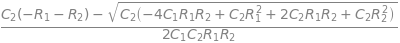

In [14]:
p = solve(H_sym_denom,s)
p[0]

In [15]:
# Generate the markdown code for a Typst equations.
temp = '$p='
temp += str(p[0]).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex1_poles>'
Typst_string

'$p=(C_2 (-R_1 - R_2) - sqrt(C_2 (-4 C_1 R_1 R_2 + C_2 R_1^2 + 2 C_2 R_1 R_2 + C_2 R_2^2)))/(2 C_1 C_2 R_1 R_2)$ <ex1_poles>'

Copy the string generated above and add Typst code for $\pm$ symbol.

```
$
p=(C_2 (-R_1 - R_2) plus.minus sqrt(C_2 (-4 C_1 R_1 R_2 + C_2 R_1^2 + 2 C_2 R_1 R_2 + C_2 R_2^2)))/(2 C_1 C_2 R_1 R_2)
$ <ex1_poles>'
```

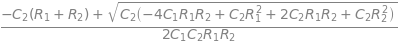

In [16]:
p[1]

Considereing the demoninator polynominal of $H(s)$, the coefficients of each Laplace term can be equated to the variables $b_2$, $b_1$ and $b_0$ in the expression: 

$b_2s^2+b_1s+b_0$

where $b_2$, $b_1$ and $b_0$ are:

In [17]:
b2 = H_sym_denom.coeff(s**2)
b1 = H_sym_denom.coeff(s**1)
b0 = (H_sym_denom - b1*s*1 - b2*s**2).expand()
Markdown('<p>$b_2={:s}$</p><p>$b_1={:s}$</p><p>$b_0={:s}$</p>'.format(latex(b2),latex(b1),latex(b0)))

<p>$b_2=C_{1} C_{2} R_{1} R_{2}$</p><p>$b_1=C_{2} R_{1} + C_{2} R_{2}$</p><p>$b_0=1$</p>

In [18]:
# Generate the markdown code for a Typst equations.
temp = '$b_2&={:s}\\nb_1&={:s}\\nb_0&={:s}$'.format(str(b2),str(b1),str(b0))
temp = temp.replace('*',' ')
Typst_string = re.sub(pattern, replacement, temp) + ' <ex1_H_denom_coef>'
Typst_string

'$b_2&=C_1 C_2 R_1 R_2\\nb_1&=C_2 R_1 + C_2 R_2\\nb_0&=1$ <ex1_H_denom_coef>'

Equating the coefficients, $\omega_n^2=\frac{b_0}{b_2}$, and rearranging the terms, $\omega_n=\sqrt {\frac{b_0}{b_2}}$, we can obtain the expression for the natural frequency in terms of the component values.

In [19]:
omega_n = sqrt(b0/b2).simplify()
Markdown('The natural frequency, $\omega_n={:s}$'.format(latex(omega_n)))

The natural frequency, $\omega_n=\sqrt{\frac{1}{C_{1} C_{2} R_{1} R_{2}}}$

In [20]:
# Generate the markdown code for a Typst equations.
temp = '$omega_n='
temp += str(omega_n.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex1_omega_n>'
Typst_string

'$omega_n=sqrt(1/(C_1 C_2 R_1 R_2))$ <ex1_omega_n>'

The coefficient of the $s$ term is:

$\frac {\omega_n}{Q}=\frac {b_1}{b_2}$

and rearranging the terms, we get the quality factor:

$Q=\frac {b_2 \omega_n}{b_1}$

In [21]:
quality_factor = (b2*omega_n/b1).simplify()
Markdown('The quality factor, $Q={:s}$'.format(latex(quality_factor)))

The quality factor, $Q=\frac{C_{1} R_{1} R_{2} \sqrt{\frac{1}{C_{1} C_{2} R_{1} R_{2}}}}{R_{1} + R_{2}}$

In [22]:
#Generate the markdown code for a Typst equations.
temp = '$Q='
temp += str(quality_factor.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex1_Q>'
Typst_string

'$Q=C_1 R_1 R_2 sqrt(1/(C_1 C_2 R_1 R_2))/(R_1 + R_2)$ <ex1_Q>'

In [23]:
zeta = (1/(2*quality_factor)).simplify()
Markdown('The damping ratio, $\zeta={:s}$'.format(latex(zeta)))

The damping ratio, $\zeta=\frac{R_{1} + R_{2}}{2 C_{1} R_{1} R_{2} \sqrt{\frac{1}{C_{1} C_{2} R_{1} R_{2}}}}$

In [24]:
#Generate the markdown code for a Typst equations.
temp = '$zeta='
temp += str(zeta.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex1_zeta>'
Typst_string

'$zeta=(R_1 + R_2)/(2 C_1 R_1 R_2 sqrt(1/(C_1 C_2 R_1 R_2)))$ <ex1_zeta>'

#### Numerical Solution
The numerical values for the components have been put into a Python dictionary called, `element_values`, when the network equations were generated for @ex1_sch. The `subs` function is used to replace the reference disignators with the componets numerical value. The following code displays the numerical network equations.

In [25]:
NE = NE_sym.subs(element_values)

temp = ''
for i in range(shape(NE.lhs)[0]):
    temp += '${:s} = {:s}$<br>'.format(latex(NE.rhs[i]),latex(NE.lhs[i]))

Markdown(temp)

$0 = I_{V1} + 2.02429149797571 \cdot 10^{-5} v_{1} - 2.02429149797571 \cdot 10^{-5} v_{3}$<br>$0 = I_{O1} + 1.0 \cdot 10^{-8} s v_{2} - 1.0 \cdot 10^{-8} s v_{3}$<br>$0 = - 1.0 \cdot 10^{-8} s v_{2} - 2.02429149797571 \cdot 10^{-5} v_{1} + v_{3} \cdot \left(1.0 \cdot 10^{-8} s + 4.04858299595142 \cdot 10^{-5}\right) - 2.02429149797571 \cdot 10^{-5} v_{4}$<br>$0 = - 2.02429149797571 \cdot 10^{-5} v_{3} + v_{4} \cdot \left(1.47 \cdot 10^{-9} s + 2.02429149797571 \cdot 10^{-5}\right)$<br>$1.0 = v_{1}$<br>$0 = v_{2} - v_{4}$<br>

The unknown node voltages and currents can be obtained as functions of the Laplace variable, `s`.

In [26]:
U = solve(NE,X)

temp = ''
for i in U.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U[i]))

Markdown(temp)

$v_{1} = 1.0$<br>$v_{2} = \frac{1.36591868959225 \cdot 10^{28}}{4.9 \cdot 10^{20} s^{2} + 1.9838056680162 \cdot 10^{24} s + 1.36591868959225 \cdot 10^{28}}$<br>$v_{3} = \frac{9.91902834008098 \cdot 10^{23} s + 1.36591868959225 \cdot 10^{28}}{4.9 \cdot 10^{20} s^{2} + 1.9838056680162 \cdot 10^{24} s + 1.36591868959225 \cdot 10^{28}}$<br>$v_{4} = \frac{1.36591868959225 \cdot 10^{28}}{4.9 \cdot 10^{20} s^{2} + 1.9838056680162 \cdot 10^{24} s + 1.36591868959225 \cdot 10^{28}}$<br>$I_{V1} = \frac{- 9.91902834008098 \cdot 10^{26} s^{2} - 2.0079004737006 \cdot 10^{30} s}{4.9 \cdot 10^{31} s^{2} + 1.9838056680162 \cdot 10^{35} s + 1.36591868959225 \cdot 10^{39}}$<br>$I_{O1} = \frac{9.91902834008098 \cdot 10^{15} s^{2}}{4.9 \cdot 10^{20} s^{2} + 1.9838056680162 \cdot 10^{24} s + 1.36591868959225 \cdot 10^{28}}$<br>

The following is some test code for formulating equations for Typst.

In [27]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in U.keys():
    temp += '{:s} &= {:s} % '.format(str(i),str(U[i]))
temp += '$'

# Remove `*`, replace `%` with `\`
temp = temp.replace('**','^').replace('*',' ').replace('%','\\n')

# Apply subscripts to most variables, some manual editing will be required.
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex1_numerical_solution>'
Typst_string
# Manually edit this string to fix any problems and copy paste into Typst.

'$v_1 &= 1.00000000000000 \\n v_2 &= 1.36591868959225e+28/(4.9e+20 s^2 + 1.9838056680162e+24 s + 1.36591868959225e+28) \\n v_3 &= (9.91902834008098e+23 s + 1.36591868959225e+28)/(4.9e+20 s^2 + 1.9838056680162e+24 s + 1.36591868959225e+28) \\n v_4 &= 1.36591868959225e+28/(4.9e+20 s^2 + 1.9838056680162e+24 s + 1.36591868959225e+28) \\n I_V_1 &= (-9.91902834008098e+26 s^2 - 2.0079004737006e+30 s)/(4.9e+31 s^2 + 1.9838056680162e+35 s + 1.36591868959225e+39) \\n I_O_1 &= 9.91902834008098e+15 s^2/(4.9e+20 s^2 + 1.9838056680162e+24 s + 1.36591868959225e+28) \\n $ <ex1_numerical_solution>'

The transfer function for the filter, $H(s)$ is the ratio $v_1/v_2$.

In [28]:
H = U[v2]/U[v1]
Markdown('$H(s) = {:s}$'.format(latex(H)))

$H(s) = \frac{1.36591868959225 \cdot 10^{28}}{4.9 \cdot 10^{20} s^{2} + 1.9838056680162 \cdot 10^{24} s + 1.36591868959225 \cdot 10^{28}}$

In [29]:
#Generate the markdown code for a Typst equations.
temp = '$H(s)='
temp += str(H.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex1_numerical_tf>'
Typst_string

'$H(s)=1.36591868959225e+28/(4.9e+20 s^2 + 1.9838056680162e+24 s + 1.36591868959225e+28)$ <ex1_numerical_tf>'

#### Frequency Response
The frequency response of the filter's transfer function can be obtained using SciPy, NumPy and Matplotlib functions. The transfer function is defined as the ratio of the output (response) to the input (excitation), assuming all initial conditions are zero.  This function, typically denoted as $H(s)$ where $s$ is the complex frequency variable $(s=j\omega)$. The following code uses `signal.bode` to generate the frequency response data over the frequency range, $10^2$ to $10^4$ Hz using `np.logspace`.

In [30]:
num, denom = fraction(H) #returns numerator and denominator

# convert symbolic to numpy polynomial
a = np.array(Poly(num, s).all_coeffs(), dtype=float)
b = np.array(Poly(denom, s).all_coeffs(), dtype=float)

x = np.logspace(2, 4, 2000, endpoint=False)*2*np.pi
w, mag, phase = signal.bode((a, b), w=x) # returns: rad/s, mag in dB, phase in deg

The follwing code calculates the 3dB cutoff frequency.

In [31]:
dc_gain = mag[0]
target_mag = dc_gain - 3.0

# Find where magnitude drops below target
idx_3db = np.where(mag <= target_mag)[0]
if len(idx_3db) > 0:
    i = idx_3db[0]
    # Interpolate linearly between adjacent points for precise frequency
    w_3db = np.interp(
        target_mag, [mag[i], mag[i - 1]], [w[i], w[i - 1]]
    )
    f_3db = w_3db / (2 * np.pi)
    print(f"3dB Cutoff Frequency: {w_3db:.3f} rad/s ({f_3db:.3f} Hz)")
else:
    print("3dB frequency not reached within frequency range.")

3dB Cutoff Frequency: 7300.410 rad/s (1161.896 Hz)


comments ....  
Calculate Gain Margin (GM) and Phase Crossover Frequency

In [32]:
# Phase crossover occurs where phase crosses -180 degrees
idx_phase_cross = np.where(phase <= -180)[0]

if len(idx_phase_cross) > 0:
    i = idx_phase_cross[0]
    # Interpolate frequency where phase is exactly -180 deg
    w_pc = np.interp(-180, [phase[i - 1], phase[i]], [w[i - 1], w[i]])
    
    # Interpolate magnitude at this frequency
    mag_at_pc = np.interp(w_pc, w, mag)
    
    # Gain Margin in dB is the difference between 0 dB and the magnitude
    gm_db = -mag_at_pc
    gm_linear = 10 ** (gm_db / 20)
    print(
        f"Gain Margin: {gm_db:.2f} dB (Linear: {gm_linear:.2f}) "
        f"at {w_pc/(2*np.pi):.3f} Hz"
    )
else:
    print("Gain Margin is Infinite (Phase never crosses -180 deg)")

Gain Margin is Infinite (Phase never crosses -180 deg)


comments ....  
Calculate Phase Margin (PM) and Gain Crossover Frequency

In [33]:
# Gain crossover occurs where magnitude crosses 0 dB
idx_gain_cross = np.where(mag <= 0)[0]

if len(idx_gain_cross) > 0:
    i = idx_gain_cross[0]
    # Interpolate frequency where magnitude is exactly 0 dB
    w_gc = np.interp(0, [mag[i], mag[i - 1]], [w[i], w[i - 1]])
    
    # Interpolate phase at this frequency
    phase_at_gc = np.interp(w_gc, w, phase)
    
    # Phase Margin is distance to -180 degrees
    pm_deg = 180 + phase_at_gc
    print(f"Phase Margin: {pm_deg:.2f} deg at {w_gc/(2*np.pi):.3f} Hz")
else:
    print("Phase Margin is Infinite (Magnitude never drops to 0 dB)")

Phase Margin: 65.67 deg at 998.508 Hz


comments ....

The Python library, Matplotlib, is used to plot the data.

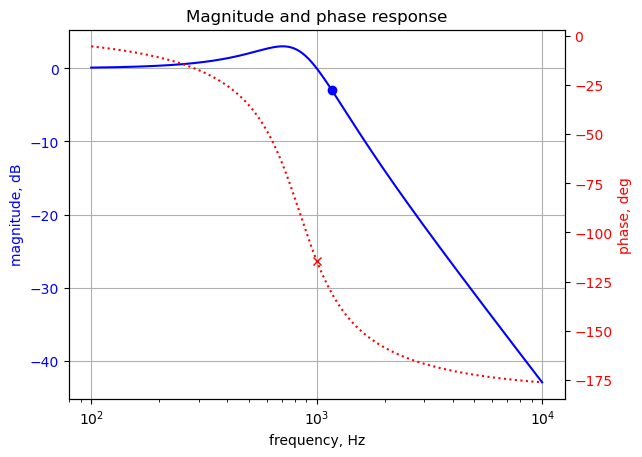

In [34]:
fig, ax1 = plt.subplots()
ax1.set_ylabel('magnitude, dB')
ax1.set_xlabel('frequency, Hz')

plt.semilogx(w/(2*np.pi), mag,'-b') # Bode magnitude plot
plt.semilogx(w[idx_3db[0]]/(2*np.pi), mag[idx_3db[0]],'ob') # plot -3dB point
ax1.set_ylabel('magnitude, dB',color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.tick_params(axis='y')
plt.grid()

# instantiate a second y-axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'r'

plt.semilogx(w/(2*np.pi), phase,':',color=color)  # Bode phase plot
plt.semilogx(w[idx_gain_cross[0]]/(2*np.pi), phase[idx_gain_cross[0]],'x',color=color)  # plot PM point

ax2.set_ylabel('phase, deg',color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Magnitude and phase response')
plt.savefig('eg1_mag_phase.png', bbox_inches='tight')
plt.show()

```
#figure(
  image("eg1_mag_phase.png", width: 70%),
  caption : [Magitude and Phase plot for example 1. The blue dot markes the -3dB location and the red X marks the phase at 0 dB of gain. The gain margin is infinite since the phase never crosses -180 deg. The phase margin is 65.67 degees at 998.508 Hz]
) <ex1_mag_phase>
```

The poles and zeros of the transfer function can easly be obtained with the following code:

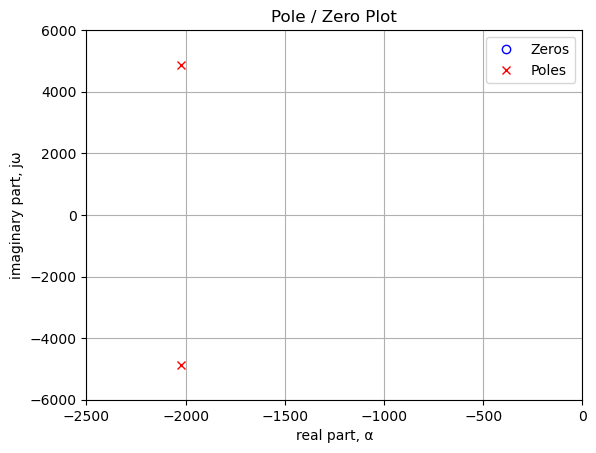

In [35]:
sys = signal.TransferFunction(a,b)

sys_zeros = np.roots(sys.num)
sys_poles = np.roots(sys.den)

plt.plot(np.real(sys_zeros), np.imag(sys_zeros), 'ob', markerfacecolor='none')
plt.plot(np.real(sys_poles), np.imag(sys_poles), 'xr')
plt.legend(['Zeros', 'Poles'], loc=0)
plt.title('Pole / Zero Plot')
plt.xlabel('real part, \u03B1')
plt.ylabel('imaginary part, j\u03C9')
plt.xlim((-2500,0))
plt.ylim((-6000,6000))
plt.grid()
plt.savefig('eg1_pole_zero.png', bbox_inches='tight')
plt.show()

```
#figure(
  image("eg1_pole_zero.png", width: 70%),
  caption : [Pole and Zero plot for example 2. Poles and zeros of the transfer function plotted on the complex plane. The units are in radian frequency. This is an all pole transfer function. Zero at $\infty$]
) <ex1_pole_zero>
```

The pole-zero plot, also known as the s-plane plot, is a graphical representation of a transfer function, $H(s)$, where the locations of its poles and zeros are marked on the complex $s$-plane. The zeros (roots of the numerator $N(s)$) are traditionally marked with a circle ($\circ$), and the poles (roots of the denominator $D(s)$) are marked with a cross ($\times$). The horizontal axis of the $s$-plane represents the real part ($\sigma$) which relates to the damping and transient response (decay or growth), while the vertical axis represents the imaginary part ($j\omega$) which relates to the oscillation frequency and sinusoidal steady-state response. This plot is a crucial visual aid because the relative positions of the poles and zeros immediately reveal key insights into the circuit's characteristics, such as its stability, natural frequencies, and how it will selectively amplify or attenuate signals at different frequencies, which is fundamental in filter design.

The proximity of a poles to the imaginary axis ($j\omega$ axis) in the pole-zero plot has a profound impact on the frequency response of the circuit. The closer a pole is to the $j\omega$ axis, the greater its influence on the magnitude of the transfer function $|H(j\omega)|$ for frequencies near the pole's imaginary part.  Specifically, a pole close to the axis corresponds to a higher Q-factor (quality factor), resulting in a sharp peak or resonance in the magnitude response curve at the pole's natural frequency, $\omega_d$ (which is the imaginary part of the pole). This means the circuit will selectively amplify signals at that specific frequency. Conversely, a pole located farther to the left (more negative real part $\sigma$) corresponds to a highly damped system, resulting in a much broader and flatter frequency response peak, or potentially no noticeable peak at all, as the system's energy quickly dissipates.

All-pole transfer functions appear across several standard filter types and system models:Classical Filter Models: Standard low-pass Butterworth, Chebyshev Type I, and Bessel filters are all-pole functions.Autoregressive (AR) Models: In digital signal processing and time-series analysis, an all-pole filter corresponds directly to an Autoregressive (AR) process or an Infinite Impulse Response (IIR) filter with feedforward coefficients set to zero (except $b_0$).Physical Systems: Overdamped or critically damped multi-stage RC low-pass networks and standard multi-stage mechanical mass-spring-damper cascades without direct feedforward paths.

General Description: "The system is modeled as an $n^{\text{th}}$-order all-pole transfer function with a constant high-frequency gain $K$."


Zeros at Infinity:
In rigorous linear systems theory and root-locus analysis, an all-pole system of order $n$ is said to have $n$ zeros at infinity because $\lim_{\vert{}s\vert{} \to \infty} \vert{}H(s)\vert{} = 0$.

Printing these values in Hz.

In [36]:
print('number of zeros: {:d}'.format(len(sys_zeros)))
for i in sys_zeros:
    print('{:,.2f} Hz'.format(i/(2*np.pi)))

number of zeros: 0


In [37]:
print('number of poles: {:d}'.format(len(sys_poles)))
for i in sys_poles:
    print('{:,.2f} Hz'.format(i/(2*np.pi)))

number of poles: 2
-322.18+776.08j Hz
-322.18-776.08j Hz


In [38]:
sys_zeros

array([], dtype=float64)

Would like to format table for printing and publication, something like:

```
#figure(
    table(
        columns: 2,
        stroke: none,
        table.header[zero/pole][value],
        [$z_0$],[$infinity$ Hz],
        [$p_1, p_2$],[-322.18 $plus.minus$ 776.08j Hz]
    ),
    caption: [Pole and zero locations],
) <ex1_pole_zero_table>
```

#### Impulse and Step Response
The impulse response, $h(t)$, and the step response, $r(t)$, are two fundamental time-domain characteristics of a circuit defined by its transfer function, $H(s)$. The impulse response is the circuit's output when the input is an ideal Dirac delta function, $\delta(t)$, which is useful because $h(t)$ is the inverse Laplace transform of the transfer function itself: $h(t) = \mathcal{L}^{-1}\{H(s)\}$. It essentially reveals the natural, unforced behavior of the system. In contrast, the step response is the output when the input is a unit step function, $u(t)$ (a signal that jumps from zero to one at $t=0$), and it is related to the impulse response by integration: $r(t) = \int_0^t h(\tau) d\tau$.  Analyzing the step response is especially practical in circuit testing as it allows engineers to easily assess key performance metrics like rise time, settling time, overshoot, and steady-state error, all of which are crucial for evaluating the speed and quality of a circuit's transient behavior.

Rise time and settling time are key metrics derived from the step response that quantify the speed and convergence of a circuit's transient behavior.

- Rise Time ($t_r$): This is the time required for the step response to go from 10% of its final value to 90% of its final value. A shorter rise time indicates a faster circuit response. It is a measure of how quickly the system can react to a sudden change in input.
- Settling Time ($t_s$): This is the time required for the step response to reach and stay within a specified tolerance band around its final, steady-state value. The tolerance band is typically 2% or 5% of the final value. A common definition uses the 2% band. A shorter settling time indicates that the oscillations or transient effects damp out quickly, meaning the circuit stabilizes faster and is a measure of the circuit's overall speed and damping.

Both measurements are essential for evaluating system performance, where rise time reflects the initial speed, and settling time reflects the overall stability and convergence of the output.

Use the SciPy functions [impulse](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.impulse.html) and [step](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.step.html) to plot the impulse and step response of the system.

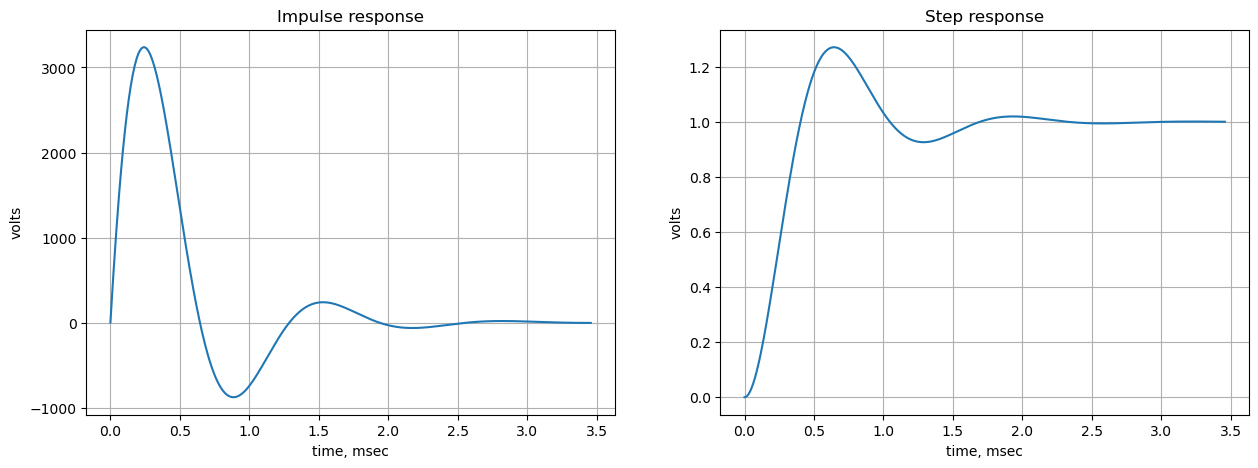

In [39]:
plt.subplots(1,2,figsize=(15, 5))

# using subplot function and creating
# plot one
plt.subplot(1, 2, 1)

# impulse response
t, y = signal.impulse(sys,N=500)
plt.plot(t/1e-3, y)
plt.title('Impulse response')
plt.ylabel('volts')
plt.xlabel('time, msec')
plt.grid()

# using subplot function and creating plot two
plt.subplot(1, 2, 2)

t, y = signal.step(sys,N=500)
plt.plot(t/1e-3, y)
plt.title('Step response')
plt.ylabel('volts')
plt.xlabel('time, msec')
plt.grid()

# show plot
plt.savefig('eg1_impulse_step.png', bbox_inches='tight')
plt.show()

```
#figure(
  image("eg1_impulse_step.png", width: 100%),
  caption : [Impulse and step response for example 1.]
) <ex1_imp_step>
```

#### Transient Analysis

Using the expression for the steady state solution obtained above, we can use SciPy to plot the transient response to a square wave.

The `scipy.signal.lsim` function is a versatile tool used in Python for simulating the time response of a continuous-time, linear time-invariant (LTI) system to an input signal.

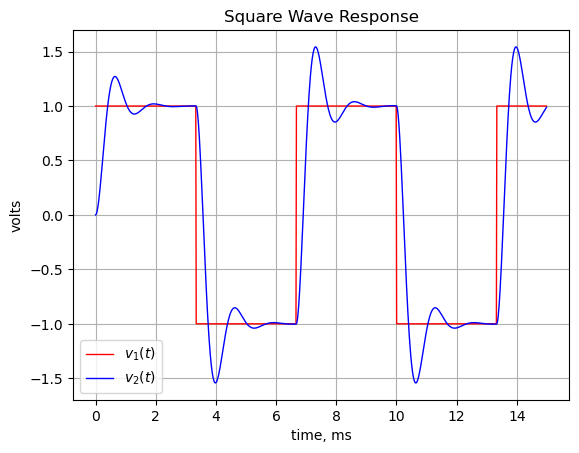

In [40]:
# Convert the expression to a continuous-time transfer function 
sys_tf = signal.TransferFunction(a,b)

# define the time interval and create a square wave
t = np.linspace(0, 15e-3, 1000, endpoint=False)
ref_sqr_signal = signal.square(2*np.pi*150*t, duty=0.5)

# call lsim to generate the response signal
ref_t_step, ref_y_step, ref_x_step = signal.lsim(sys_tf, U=ref_sqr_signal, T=t)

plt.plot(ref_t_step*1e3, ref_sqr_signal, 'r', alpha = 1.0, linewidth=1, label='$v_1(t)$')
plt.plot(ref_t_step*1e3, ref_y_step,'b', linewidth = 1.0, label='$v_2(t)$')
plt.title('Square Wave Response')
plt.ylabel('volts')
plt.xlabel('time, ms')
plt.grid()
plt.legend(loc='best')
plt.savefig('eg1_sqrwave.png', bbox_inches='tight')
# show plot
plt.show()

```
#figure(
  image("eg1_sqrwave.png", width: 100%),
  caption : [Squarewave response for example 1.]
) <ex1_sqrwave>
```

In this example we have shown that a circuit's network equations can easily be generated from a schematic by importing the netlist generated from the schematic capture tool. Then SYmPy can be used to solve the network equations to obtain the transfer function. NumPy and SciPy can be used to analyize the circuit and obtain the typical performance plots. 


### 2) Mutual Inductance
In this example the schematic in @ex2_sch models the essential elements of wireless power transfer system. $L_1$ and $L_2$ are two mutually coupled inductors seperated by a small air gap. $C_1$ and $C_2$ represent the capacitance in the circuit that causes the circuit to resonate at the desired frequency. $R_1$ represents the source inpedance of $V_1$ as well as any other losses on the transmitting side including the resistance in $L_1$. $R_2$ represents the load as well as any internal resistance of $L_2$. $K$ is the coupling coefficient and can be any number between -1 and +1. A value for $K$ would typically range from 0.1 to 0.45 for wireless charging of small devices and is depentend on seperation and alligment of the coils. There are phase dots shown on $L_1$ and $L_2$. Since the phase dots are orientated on the same ends of the coils, the voltage in each winding is in phase. 

![Mutual inductance schematic.](Wireless_power_transfer_v0.png)

```
Typst  
#figure(
  image("Wireless_power_transfer_v0.png", width: 70%),
  caption : [Schematic of two coupled inductors.]
) <ex2_sch>
```

In [41]:
ft=100e3
L1=5e-6
C1=((1/(ft*2*np.pi))**2)/L1
C1

In [42]:
C1=5e-7
ft = 1/(2*np.pi*np.sqrt(C1*L1))
ft

In [43]:
L2=47e-6
C2=((1/(ft*2*np.pi))**2)/L2
C2

In [44]:
C2=53e-9
fr = 1/(2*np.pi*np.sqrt(C2*L2))
fr

The netlist generated by LTSpice is pasted into the cell below and some edits were made to remove the inductor series resistance. 

In [45]:
ex2_net_list = '''
* Wireless_power_transfer_v0.asc
V1 1 0 1
R1 2 1 1
R2 4 0 100
C1 3 2 0.5e-6
C2 4 0 53e-9
L1 0 3 5e-6
L2 0 4 47e-6
K L1 L2 0.5
'''

report, network_df, df2, A, X, Z = SymMNA.smna(ex2_net_list)

# Put matrices into SymPy 
X = Matrix(X)
Z = Matrix(Z)

NE_sym = Eq(A*X,Z)

# The symbols generated by the Python code are extracted by the SymPy function free_symbols
# and then declared as SymPy variables.
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

K = symbols('K') # declare a symbol for the coupling coefficient

# built a dictionary of element values.
element_values = SymMNA.get_part_values(network_df)

# generate markdown text to display the network equations.
temp = ''
for i in range(len(X)):
    temp += '${:s}$<br>'.format(latex(Eq((A*X)[i:i+1][0],Z[i])))

Markdown(temp)

$I_{V1} + \frac{v_{1}}{R_{1}} - \frac{v_{2}}{R_{1}} = 0$<br>$- C_{1} s v_{3} + v_{2} \left(C_{1} s + \frac{1}{R_{1}}\right) - \frac{v_{1}}{R_{1}} = 0$<br>$- C_{1} s v_{2} + C_{1} s v_{3} - I_{L1} = 0$<br>$- I_{L2} + v_{4} \left(C_{2} s + \frac{1}{R_{2}}\right) = 0$<br>$v_{1} = V_{1}$<br>$- I_{L1} L_{1} s - I_{L2} M s - v_{3} = 0$<br>$- I_{L1} M s - I_{L2} L_{2} s - v_{4} = 0$<br>

Generate the markdown code for Typst equations.

In [46]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in range(shape(NE_sym.lhs)[0]):
    temp += '{:s} &= {:s} % '.format(str(NE_sym.rhs[i]),str(NE_sym.lhs[i]))
temp += '$'

# Remove `*`, replace `%` with `\`, subscript most variables.
temp = temp.replace('*','').replace('%','\\n')

# Apply subscripts to most variables, some manual editing will be required.
new_string = re.sub(pattern, replacement, temp) + ' <ex2_network_equ>'
new_string
# Manually edit this string to fix any problems and copy paste into Typst.

'$0 &= I_V_1 + v_1/R_1 - v_2/R_1 \\n 0 &= -C_1sv_3 + v_2(C_1s + 1/R_1) - v_1/R_1 \\n 0 &= -C_1sv_2 + C_1sv_3 - I_L_1 \\n 0 &= -I_L_2 + v_4(C_2s + 1/R_2) \\n V_1 &= v_1 \\n 0 &= -I_L_1L_1s - I_L_2Ms - v_3 \\n 0 &= -I_L_1Ms - I_L_2L_2s - v_4 \\n $ <ex2_network_equ>'

These equations can be solved with SymPy.

In [47]:
%%time
U_sym = solve(NE_sym,X)

CPU times: user 93.2 ms, sys: 0 ns, total: 93.2 ms
Wall time: 93.6 ms


Display the symbolic solution

In [48]:
temp = ''
for i in U_sym.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_sym[i]))

Markdown(temp)

$v_{1} = V_{1}$<br>$v_{2} = \frac{C_{1} C_{2} L_{1} L_{2} R_{2} V_{1} s^{4} - C_{1} C_{2} M^{2} R_{2} V_{1} s^{4} + C_{1} L_{1} L_{2} V_{1} s^{3} + C_{1} L_{1} R_{2} V_{1} s^{2} - C_{1} M^{2} V_{1} s^{3} + C_{2} L_{2} R_{2} V_{1} s^{2} + L_{2} V_{1} s + R_{2} V_{1}}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>$v_{3} = \frac{C_{1} C_{2} L_{1} L_{2} R_{2} V_{1} s^{4} - C_{1} C_{2} M^{2} R_{2} V_{1} s^{4} + C_{1} L_{1} L_{2} V_{1} s^{3} + C_{1} L_{1} R_{2} V_{1} s^{2} - C_{1} M^{2} V_{1} s^{3}}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>$v_{4} = \frac{C_{1} M R_{2} V_{1} s^{2}}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>$I_{V1} = \frac{- C_{1} C_{2} L_{2} R_{2} V_{1} s^{3} - C_{1} L_{2} V_{1} s^{2} - C_{1} R_{2} V_{1} s}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>$I_{L1} = \frac{- C_{1} C_{2} L_{2} R_{2} V_{1} s^{3} - C_{1} L_{2} V_{1} s^{2} - C_{1} R_{2} V_{1} s}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>$I_{L2} = \frac{C_{1} C_{2} M R_{2} V_{1} s^{3} + C_{1} M V_{1} s^{2}}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>

The transfer function of the voltages on nodes $v_1$ and $v_2$ is shown below. As you can see, this is a fourth order system. Notice that the mutual inductance, $M$, has been introduced into the equations.

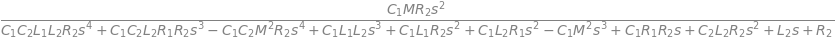

In [49]:
H_sym = U_sym[v4]/U_sym[v1]
H_sym

The value of $K$ can be from -1 to +1 to account for a negative phase relation. Phase dots are drawn on the schematic to indicate the relative direction of the windings. In LTspice the phase dots are associated with the negative terminal of the winding. The coupling constant and the mutual inductance are related by the equation: $K = \frac {M}{\sqrt{L_1 \times L_2}}$

Below, $M$ is calculated and added to the element value dictionary.

In [50]:
# calculate the mutual inductance from the coupling constant
element_values[M] = element_values[K]*np.sqrt(element_values[L1] *element_values[L2])
print('mutual inductance, M = {:.9f}'.format(element_values[M]))

mutual inductance, M = 0.000007665


After substituting the numeric component values for the elements, a numerical solution for the note voltages can be obtained for the steady state condition.

In [51]:
NE = NE_sym.subs(element_values)

U = solve(NE,X)

The frequency response plot of the transfer function $H(s)=\frac{v_2}{v_1}$ is plotted with the code below.

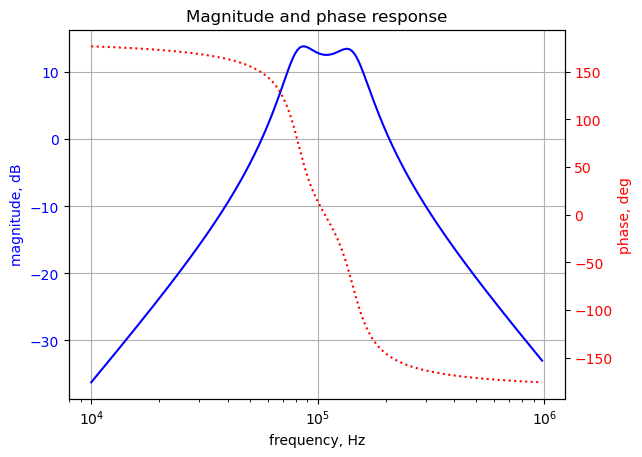

In [52]:
H = U[v4]/U[v1]
H_num, H_denom = fraction(H) #returns numerator and denominator

# convert symbolic to NumPy polynomial
a = np.array(Poly(H_num, s).all_coeffs(), dtype=float)
b = np.array(Poly(H_denom, s).all_coeffs(), dtype=float)

x = np.logspace(4, 6, 200, endpoint=False)*2*np.pi
w, mag, phase = signal.bode((a,b), w=x) # returns: rad/s, mag in dB, phase in deg

fig, ax1 = plt.subplots()
ax1.set_ylabel('magnitude, dB',color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlabel('frequency, Hz')

plt.semilogx(w/(2*np.pi), mag,'-b')    # Bode magnitude plot

ax1.tick_params(axis='y')
plt.grid()

# instantiate a second y-axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'r'

plt.semilogx(w/(2*np.pi), phase,':',color=color)  # Bode phase plot

ax2.set_ylabel('phase, deg',color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Magnitude and phase response')
plt.savefig('eg2_mag_phase.png', bbox_inches='tight')
plt.show()

```
#figure(
  image("eg2_mag_phase.png", width: 70%),
  caption : [Mag and Phase for example 2.]
) <ex2_mag_phase>
```

Using the expression for the steady state solution obtained above, we can use SciPy to plot the transient response to a square wave.

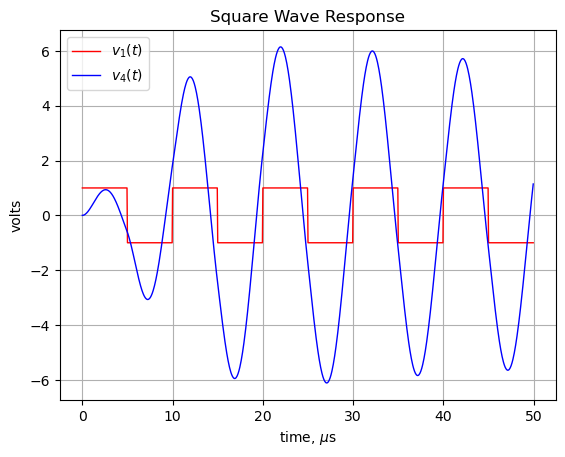

In [53]:
sys_tf = signal.TransferFunction(a,b)

# define the time interval and create a square wave
t = np.linspace(0, 0.00005, 1000, endpoint=False)
ref_sqr_signal = signal.square(2*np.pi*1e5*t, duty=0.5)

# call lsim to generate the response signal
ref_t_step, ref_y_step, ref_x_step = signal.lsim(sys_tf, U=ref_sqr_signal, T=t)

plt.plot(ref_t_step*1e6, ref_sqr_signal, 'r', alpha = 1.0, linewidth=1, label='$v_1(t)$')
plt.plot(ref_t_step*1e6, ref_y_step,'b', linewidth = 1.0, label='$v_4(t)$')
plt.title('Square Wave Response')
plt.ylabel('volts')
plt.xlabel('time, $\mu$s')
plt.grid()
plt.legend(loc='best')
plt.savefig('eg2_sqrwave.png', bbox_inches='tight')
# show plot
plt.show()

```
#figure(
  image("eg2_sqrwave.png", width: 100%),
  caption : [Squarewave response for example 2.]
) <ex2_sqrwave>
```
comments ...

### 3) Initial Conditions
In this example, the initial conditions for capacitors and inductors are explored. Initial conditions refer to the state of the energy storing elements, capacitor and inductors, at $t = 0$, the point in time where the analysis starts. In s-domain analysis, the initial conditions are included in the analysis by using auxiliary sources in the transformed models of the capacitors and inductors. 

Unless the initial conditions are specified, the voltage on the capacitors and the current through the inductors are assumed to be zero. Initial conditions for capacitors and inductors are essential in transient circuit analysis as they represent the energy stored in these components immediately prior to a change in the circuit, such as a switch opening or closing at time $t=0$. 

Mathematically, this is expressed as $v_C(0^-) = 0$ then $v_C(0) = V_{ic}$ and $i_L(0^-) = 0$ then $i_L(0)=I_{ic}$, where $0^-$ is the first instant of time to the left of $t=0$. Some engineering text books use $v_C(0^-) = v_C(0)$ and $i_L(0^-) = i_L(0)$, others use $v_C(0) = v_C(0^+)$ and $i_L(0) = i_L(0^+)$. So depending on which text book is consulted, there can be different ways of describing the value of the initial conditions at the time origin. Some of these inconsistencies are explored in @Lundberg2007.

#### Initial Capacitor Voltage
In the analysis presented in this example, capacitors are assumed to have an initial condition described in terms of an initial voltage across its terminals. This is modeled with a series DC step-voltage source of value $\frac{v_C(0^-)}{s}$. The added series voltage source is the s-domain abstraction of the initial energy stored in the capacitor expressed in terms of voltage. The schematic of this is shown in @fig-Cap_Ind_init_cond_model_v0, where the capacitor is replaced by:  

$\underbrace{\frac{1}{Cs}}_{\text{Impedance}} + \underbrace{\frac{v_C(0^-)}{s}}_{\text{Series voltage source}}$

#### Initial Inductor Current
Inductors in the network that have initial conditions, have initial conditions described in terms of an initial current flowing in the inductor at $t=0$. This is modeled by a DC step-current source of value $\frac{i_L(0^-)}{s}$. The parallel current source is the s-domain abstraction of the inductor's internal magnetic field. The schematic of this is shown in @fig-Cap_Ind_init_cond_model_v0, where the inductor is replaced by:  

$\underbrace{{Ls}}_{\text{Impedance}}  \parallel \underbrace{\frac{i_L(0^-)}{s}}_{\text{Parallel current source}}$

@fig-initial_conditions_example_4_v0_combined shows the model for initial conditions used in this chapter for capacitors and inductors. Part (a) Shows the orginal circuit where the initial voltage on $C_1$ and the initial current in $L_1$ are modeled by the elements shown in part (b). Although it is possible to describe initial conditions for capacitors in terms of current, I think it is more intuitive to think about a capacitor as having an initial voltage as the initial condition at $t=0$. The polarity of $V$, can be changed either by changing the orientation of the symbol in the schematic before the netlist is generated or by changing the sign of the value of the initial voltage. The initial condition for inductors can also be described in terms of an initial voltage, I think it is more natural to describe the initial condition in terms of current present in the inductor at $t=0$. The direction of the arrow in the current symbol in the LTSpice schematic can be confusing since the convention used is that the positive direction is out of node 1 in the figure below, which is opposite to the direction of the arrow on the current symbol.   

![The orginal circuit is shown in (a). (b) shows the initial conditions modeled by adding independent sources to the element branches.](Initial_conditions_v0_combined.png)  
```
Typst  
#figure(
  image("Initial_conditions_combined.png", width: 50%),
  caption : [This ???.]
) <example_3_sch_1>
```

The schematic in @example_3_sch_2> has seven branches and four nodes. $V_1$ represents the initial voltage on $C_2$ and $I_1$ represents the initial current in $L_2$.

![Initial conditions test circuit.](Initial_conditions_v1.png)

```
Typst  
#figure(
  image("Initial_conditions_v1.png", width: 50%),
  caption : [This ???.]
) <example_3_sch_2>
```

The circuit was drawn using LTSpice and the netlist was pasted into the code.

The code below assembles the network equations from the MNA matrices and displays the equations.

In [54]:
ex3_net_list = '''
* Initial_conditions_example_4_v1.asc
L1 1 2 1e-3
C1 1 3 1e-6
R1 2 0 10
V1 3 0 1
I1 2 1 1
'''

report, network_df, i_unk_df, A, X, Z = SymMNA.smna(ex3_net_list)

# Put matrices into SymPy 
X = Matrix(X)
Z = Matrix(Z)

# put the matrices into equation form 
NE_sym = Eq(A*X,Z)

# free symbols are entered as SymPy variables
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

# the element values are put into a dictionary
element_values = SymMNA.get_part_values(network_df) # get element values from netlist

# display the equations
temp = ''
for i in range(shape(NE_sym.lhs)[0]):
    temp += '${:s} = {:s}$<br>'.format(latex(NE_sym.rhs[i]),latex(NE_sym.lhs[i]))
Markdown(temp)

$I_{1} = C_{1} s v_{1} - C_{1} s v_{3} + I_{L1}$<br>$- I_{1} = - I_{L1} + \frac{v_{2}}{R_{1}}$<br>$0 = - C_{1} s v_{1} + C_{1} s v_{3} + I_{V1}$<br>$V_{1} = v_{3}$<br>$0 = - I_{L1} L_{1} s + v_{1} - v_{2}$<br>

Generate the markdown code for Typst equations.

In [55]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in range(shape(NE_sym.lhs)[0]):
    temp += '{:s} &= {:s} % '.format(str(NE_sym.rhs[i]),str(NE_sym.lhs[i]))
temp += '$'

# Remove `*`, replace `%` with `\`, subscript most variables.
temp = temp.replace('*','').replace('%','\\n')

# Apply subscripts to most variables, some manual editing will be required.
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp) + ' <ex3_network_equ>'
new_string
# Manually edit this string to fix any problems and copy paste into Typst.

'$I_1 &= C_1sv_1 - C_1sv_3 + I_L_1 \\n -I_1 &= -I_L_1 + v_2/R_1 \\n 0 &= -C_1sv_1 + C_1sv_3 + I_V_1 \\n V_1 &= v_3 \\n 0 &= -I_L_1L_1s + v_1 - v_2 \\n $ <ex3_network_equ>'

The initial conditions for $C_2$ and $L_2$ are set by $V_1$ and $I_1$. A step function with values of 1 is used for $V_1$ and $I_1$.

In [56]:
element_values[V1] = element_values[V1]/s
element_values[I1] = element_values[I1]/s
NE_ic = NE_sym.subs(element_values)

# display the equations
temp = ''
for i in range(shape(NE_ic.lhs)[0]):
    temp += '${:s} = {:s}$<br>'.format(latex(NE_ic.rhs[i]),latex(NE_ic.lhs[i]))
Markdown(temp)

$\frac{1.0}{s} = I_{L1} + 1.0 \cdot 10^{-6} s v_{1} - 1.0 \cdot 10^{-6} s v_{3}$<br>$- \frac{1.0}{s} = - I_{L1} + 0.1 v_{2}$<br>$0 = I_{V1} - 1.0 \cdot 10^{-6} s v_{1} + 1.0 \cdot 10^{-6} s v_{3}$<br>$\frac{1.0}{s} = v_{3}$<br>$0 = - 0.001 I_{L1} s + v_{1} - v_{2}$<br>

Solve the network equations and display the results.

In [57]:
U_ic = solve(NE_ic,X)

temp = ''
for i in U_ic.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_ic[i]))

Markdown(temp)

$v_{1} = \frac{s + 1010000.0}{s^{2} + 10000.0 s + 1000000000.0}$<br>$v_{2} = \frac{10000.0 - 10.0 s}{s^{2} + 10000.0 s + 1000000000.0}$<br>$v_{3} = \frac{1}{s}$<br>$I_{V1} = \frac{s - 1000.0}{s^{2} + 10000.0 s + 1000000000.0}$<br>$I_{L1} = \frac{11000.0 s + 1000000000.0}{s^{3} + 10000.0 s^{2} + 1000000000.0 s}$<br>

The voltage at node 1 is:

In [58]:
node_1_voltage_s = U_ic[v1].nsimplify()
node_1_voltage_s

In [59]:
# Generate the markdown code for a Typst equations.
temp = '$v_1(s)='
temp += str(node_1_voltage_s.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex3_v1_s>'
Typst_string

'$v_1(s)=(s + 1010000)/(s^2 + 10000 s + 1000000000)$ <ex3_v1_s>'

Declare the symbol $t$ to be used as the time variable.

In [60]:
t = symbols('t',positive=True)  # t > 0

Find the inverse Laplace transform using the SymPy function, `inverse_laplace_transform`.

In [61]:
%%time
node_1_voltage_t = inverse_laplace_transform(node_1_voltage_s, s, t)

CPU times: user 7.81 s, sys: 0 ns, total: 7.81 s
Wall time: 7.85 s


In [62]:
node_1_voltage_t

In [63]:
# Generate the markdown code for a Typst equations.
temp = '$v_1(s)='
temp += str(node_1_voltage_t.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n').replace('exp','e^')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex3_v1_t>'
Typst_string

'$v_1(s)=(67 sqrt(39) sin(5000 sqrt(39) t) + 13 cos(5000 sqrt(39) t)) e^(-5000 t)/13$ <ex3_v1_t>'

Use lambdify to generate a function of time.

In [64]:
func_node_1_voltage_t = lambdify(t, node_1_voltage_t) 

The inverse Laplace is obtained for node voltage 2 with the following code.  

In [65]:
node_2_voltage_s = U_ic[v2].nsimplify()
node_2_voltage_s

In [66]:
# Generate the markdown code for a Typst equations.
temp = '$v_1(s)='
temp += str(node_2_voltage_s.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex3_v2_s>'
Typst_string

'$v_1(s)=(10000 - 10 s)/(s^2 + 10000 s + 1000000000)$ <ex3_v2_s>'

In [67]:
%%time
node_2_voltage_t = inverse_laplace_transform(node_2_voltage_s, s, t)

CPU times: user 7.09 s, sys: 0 ns, total: 7.09 s
Wall time: 7.1 s


In [68]:
node_2_voltage_t

In [69]:
# Generate the markdown code for a Typst equations.
temp = '$v_1(s)='
temp += str(node_2_voltage_t.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n').replace('exp','e^')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex3_v2_t>'
Typst_string

'$v_1(s)=(4 sqrt(39) sin(5000 sqrt(39) t) - 130 cos(5000 sqrt(39) t)) e^(-5000 t)/13$ <ex3_v2_t>'

Use lambdify to generate a function of time.

In [70]:
func_node_2_voltage_t = lambdify(t, node_2_voltage_t) 

In [71]:
%%time
V1_current_s = U_ic[I_V1].nsimplify()

CPU times: user 23 ms, sys: 49 µs, total: 23 ms
Wall time: 22.9 ms


In [72]:
V1_current_s

In [73]:
# Generate the markdown code for a Typst equations.
temp = '$I_{v_1}(s)='
temp += str(V1_current_s.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex3_I_V1_s>'
Typst_string

'$I_{v_1}(s)=(s - 1000)/(s^2 + 10000 s + 1000000000)$ <ex3_I_V1_s>'

In [74]:
%%time
V1_current_t = inverse_laplace_transform(V1_current_s, s, t)

CPU times: user 7.21 s, sys: 0 ns, total: 7.21 s
Wall time: 7.22 s


In [75]:
V1_current_t

In [76]:
# Generate the markdown code for a Typst equations.
temp = '$I_{V_1}(t)='
temp += str(V1_current_t.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n').replace('exp','e^')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex3_I_V1_t>'
Typst_string

'$I_{V_1}(t)=(-2 sqrt(39) sin(5000 sqrt(39) t) + 65 cos(5000 sqrt(39) t)) e^(-5000 t)/65$ <ex3_I_V1_t>'

Use lambdify to generate a function of time.

In [77]:
func_V1_current_t = lambdify(t, V1_current_t) 

The frequeny domain expression for the current in $L_1$ is shown below. 

In [78]:
L1_current_s = U_ic[I_L1].nsimplify()
L1_current_s

In [79]:
# Generate the markdown code for a Typst equations.
temp = '$I_{L_1}(s)='
temp += str(L1_current_s.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex3_I_L1_s>'
Typst_string

'$I_{L_1}(s)=(11000 s + 1000000000)/(s^3 + 10000 s^2 + 1000000000 s)$ <ex3_I_L1_s>'

Since the current for $L_1$ has a third order demoninator, using the standard SymPy inverse Laplace transform function will take a long time, if ever, to obtain the inverse function, we insted obtain the inverse transform by find the partial fraction expansion of the expression. The code shown below was inspired by the answer given by _Davide_sd_ for the question in @zorka5.

In [80]:
n, d = fraction(L1_current_s) # get the numerator and denominator for the expression.

n = n.expand() # expand the numerator to get the individual additive terms

In [81]:
# Each of the numerator terms can be put over the common denominator.
if len(Add.make_args(n)) > 1: # check for the number of additive terms in the numerator
    terms = [a / d for a in n.args]
else:
    terms = [n/d]

In [82]:
terms[0]

In [83]:
# Generate the markdown code for a Typst equations.
temp = '$'
temp += str(terms[0].collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex3_term0>'
Typst_string

'$1000000000/(s^3 + 10000 s^2 + 1000000000 s)$ <ex3_term0>'

In [84]:
terms[1]

In [85]:
# Generate the markdown code for a Typst equations.
temp = '$'
temp += str(terms[1].collect(s)).replace('**','^').replace('*',' ').replace('%','\\n')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex3_term1>'
Typst_string

'$11000 s/(s^3 + 10000 s^2 + 1000000000 s)$ <ex3_term1>'

The following code processes each of the terms obtained above. 
- the SciPy function [residue](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.residue.html) is used to get the residues and poles of the partial-fraction expansion
- r: Residues corresponding to the poles. For repeated poles, the residues are ordered to correspond to ascending by power fractions.
- p: Poles ordered by magnitude in ascending order.
- k: Coefficients of the direct polynomial term.
When computing the inverse Laplace transform, the Coefficients (k) are ignored since these transform to a Dirac delta function, $\delta (t)$ and don't need to be plotted.

In [86]:
N = []
for p1 in terms:

    # use the SciPy residue function to get the partial-fraction expansion residues and poles
    n, d = fraction(p1)
    cn = Poly(n, s).all_coeffs()
    cd = Poly(d, s).all_coeffs()
    r, p, k = signal.residue(cn, cd, tol=0.001, rtype='avg')

    # build a symbolic expression for each of the residues and find the inverse Laplace of each one
    z = 0
    for i in range(len(r)):
        m = (r[i]/(s-p[i]))
        z += inverse_laplace_transform(m, s, t)

    N.append(z)

In [87]:
len(N)

In [88]:
element_values = SymMNA.get_part_values(network_df)
N_terms = N[0]+N[1]-element_values[I1]
N_terms

In [89]:
# Generate the markdown code for a Typst equations.
temp = '$N(t)='
temp += str(N_terms.collect(s)).replace('**','^').replace('*',' ').replace('%','\\n').replace('I','j').replace('exp','e^')+'$'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex3_Nterms>'
Typst_string

'$N(t)=0.176140969185596 (sin(31224.989991992 t) - j cos(31224.989991992 t)) e^(-5000.0 t) - (0.5 + 0.0800640769025436 j) e^(-5000.0 t - 31224.989991992 j t) + 0.176140969185596 j e^(-5000.0 t - 31224.989991992 j t) - (0.5 - 0.0800640769025436 j) e^(-5000.0 t + 31224.989991992 j t)$ <ex3_Nterms>'

The inverse Laplace for each of the terms is shown below.

Use lambdify to generate a function of time.

In [90]:
# Each of these terms can be converted to a function using SymPy's [lambdify](https://docs.sympy.org/latest/modules/utilities/lambdify.html) function.
# Define the values for the x-axis of the plot and put into an array for plotting.
x = np.linspace(0, 1e-3, 2000, endpoint=True)
func_L1_current_t = np.zeros(len(x),dtype = complex)
for p in N:
    func_L1_current_t += lambdify(t, p)(x)

Plot the voltages and currents.

Don't plot inductor current, since it needs a fix-up 

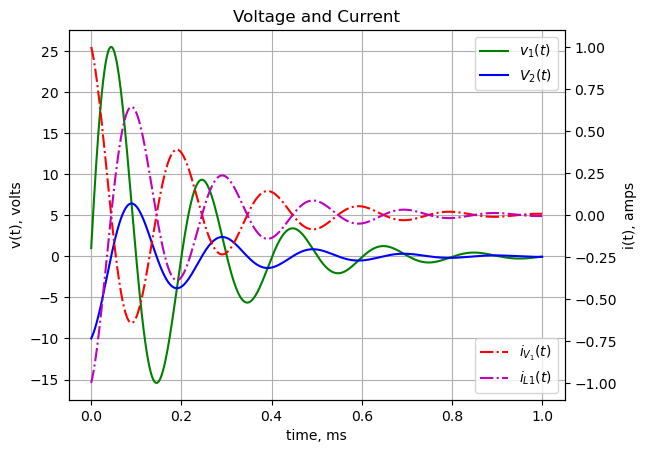

In [91]:
fig, ax1 = plt.subplots()
ax1.set_ylabel('v(t), volts')
ax1.set_xlabel('time, ms')

# plot voltages
plt.plot(x*1000, func_node_1_voltage_t(x),'-g',label='$v_1(t)$')
plt.plot(x*1000, func_node_2_voltage_t(x),'-b',label='$V_2(t)$')

ax1.tick_params(axis='y')
plt.legend(loc='upper right')
plt.grid()

# instantiate a second y-axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'k'

# plot currents
plt.plot(x*1000, func_V1_current_t(x),'-.r',label='$i_{V_1}(t)$')
plt.plot(x*1000, np.real(func_L1_current_t)-1,'-.m',label='$i_{L1}(t)$')

ax2.set_ylabel('i(t), amps',color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.legend(loc='lower right')
plt.title('Voltage and Current')
plt.savefig('eg3_step.png', bbox_inches='tight')
plt.show()

<!--
Typst  
#figure(
  image("??.png", width: 50%),
  caption : [This .]
) <example_5_plot>
-->
Notice that the plot for $i_{L1}(t)$ has an offset equal to the value of $I_1$. However, this is not what we would expect when $L_1$ has an initial condition of $i_{L_1}=1$, since $i(t)$ should $\to 0$, due to the losses in the circuit from $R_1$. Using $\frac{I_1}{s}$ to represent the initial conditions in $L_1$ produces correct node voltages, but the solution for the current in $L_1$ needs to be adjusted. In this example, offsetting the current in the inductor by -1 would correct the result at $t=0$ and as $t \to \infty$. 

### 4) Superposition Example

- ~Change example title to Superposition~
- controlled sources

The final example is the circuit shown in @example_6_sch. This circuit has a varity of dependent and independent sources. There are 13 branches in the circuit and eight nodes in the circuit. The circuit has six resistors, one capacitor and one inductor along with two independent voltage sources and one independent current source. 

This circuit has eight nodes and about six loops depending on how you want to set the problem up; and is arguably a bit too complicated to be included in a typical college engineering text on linear circuit analysis. This is espically true if the student was expected to perform the circuit analysis by hand with pencil and paper. Using the examples presented in this paper, the examples can serve as templates to obtain symbolic solutions for small to meadium size ciruits and numerical solutions for larger circuits.

$V_1$ is an independent AC voltage source, $I_1$ is an independent DC current source, $G$ is a voltage controlled current source (VCCS) and $H$ is a current controlled voltage source (CCVS), with the controlling current determined by the current in $V_2$, which has a voltage value of zero.

The circuit analysis involves a two-step process based on the superposition theorem.

Step 1: The DC operating point of the circuit is calculated by setting:
- DC voltage and current sources are set to their specified values.
- All independent AC sources are set to zero.
- The Laplace variable, $s=j \omega$ is zero since $\omega=0$.

Step 2: The frequency-Domain AC Analysis is calculated by setting:
- All independent DC sources are set to zero. They set the operating point in Step 1, but contribute zero signal amplitude in Step 2.
- The AC source generates a unit sinusoidal signal at the frequencies specified when $\omega$ is assigned a value.

![This schematic contains a variety of sources.](Superposition_example_v0.png)

Redraw showing values and phases of the sources

```
Typst  
#figure(
  image("Superposition_example_v0.png", width: 50%),
  caption : [This schematic contains a variety of sources.]
) <example_4_sch>
```

Think about adding a new independent AC source with frequency $\omega_2$ between node 1 and GND.

In [92]:
ex4_net_list = '''
I1 6 1 3
G 6 3 4 7 1
H 7 0 V2 3
V1 1 5 10
C1 4 5 0.1
L1 6 8 4
R1 2 3 5
R2 5 7 3
R3 6 5 9
V2 1 2 0
R5 8 0 1
R7 1 4 7
R8 1 6 2
V3 9 0 3
R4 1 9 2
'''

# generate the MNA matrices. 
report, network_df, i_unk_df, A, X, Z = SymMNA.smna(ex4_net_list)

# Put matrices into SymPy 
X = Matrix(X)
Z = Matrix(Z)

# assemble the system of equations
NE_sym = Eq(A*X,Z)

# turn the free symbols into SymPy variables.
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

# display the network equations
temp = ''
for i in range(len(X)):
    temp += '${:s}$<br>'.format(latex(Eq((A*X)[i:i+1][0],Z[i])))

Markdown(temp)

$I_{V1} + I_{V2} + v_{1} \cdot \left(\frac{1}{R_{8}} + \frac{1}{R_{7}} + \frac{1}{R_{4}}\right) - \frac{v_{6}}{R_{8}} - \frac{v_{4}}{R_{7}} - \frac{v_{9}}{R_{4}} = I_{1}$<br>$- I_{V2} + \frac{v_{2}}{R_{1}} - \frac{v_{3}}{R_{1}} = 0$<br>$- g v_{4} + g v_{7} - \frac{v_{2}}{R_{1}} + \frac{v_{3}}{R_{1}} = 0$<br>$- C_{1} s v_{5} + v_{4} \left(C_{1} s + \frac{1}{R_{7}}\right) - \frac{v_{1}}{R_{7}} = 0$<br>$- C_{1} s v_{4} - I_{V1} + v_{5} \left(C_{1} s + \frac{1}{R_{3}} + \frac{1}{R_{2}}\right) - \frac{v_{6}}{R_{3}} - \frac{v_{7}}{R_{2}} = 0$<br>$I_{L1} + g v_{4} - g v_{7} + v_{6} \cdot \left(\frac{1}{R_{8}} + \frac{1}{R_{3}}\right) - \frac{v_{1}}{R_{8}} - \frac{v_{5}}{R_{3}} = - I_{1}$<br>$I_{H} - \frac{v_{5}}{R_{2}} + \frac{v_{7}}{R_{2}} = 0$<br>$- I_{L1} + \frac{v_{8}}{R_{5}} = 0$<br>$I_{V3} - \frac{v_{1}}{R_{4}} + \frac{v_{9}}{R_{4}} = 0$<br>$v_{1} - v_{5} = V_{1}$<br>$v_{1} - v_{2} = V_{2}$<br>$v_{9} = V_{3}$<br>$- I_{V2} h + v_{7} = 0$<br>$- I_{L1} L_{1} s + v_{6} - v_{8} = 0$<br>

In [93]:
print(report)

Net list report
number of lines in netlist: 15
number of branches: 15
number of nodes: 9
number of unknown currents: 5
number of RLC (passive components): 9
number of resistors: 7
number of capacitors: 1
number of inductors: 1
number of independent voltage sources: 3
number of independent current sources: 1
number of Op Amps: 0
number of E - VCVS: 0
number of G - VCCS: 1
number of F - CCCS: 0
number of H - CCVS: 1
number of K - Coupled inductors: 0



Notice in the equations above, the gain terms for the VCCS, $G$, and CCVS, $H$, are written as lower case $g$ and $h$.

Generate the markdown code for Typst equations.

In [94]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in range(shape(NE_sym.lhs)[0]):
    temp += '{:s} &= {:s} % '.format(str(NE_sym.rhs[i]),str(NE_sym.lhs[i]))
temp += '$'

# Remove `*`, replace `%` with `\`, subscript most variables.
temp = temp.replace('*','').replace('%','\\n')

# Apply subscripts to most variables, some manual editing will be required.
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp) + ' <ex4_network_equ>'
new_string

'$I_1 &= I_V_1 + I_V_2 + v_1(1/R_8 + 1/R_7 + 1/R_4) - v_6/R_8 - v_4/R_7 - v_9/R_4 \\n 0 &= -I_V_2 + v_2/R_1 - v_3/R_1 \\n 0 &= -gv_4 + gv_7 - v_2/R_1 + v_3/R_1 \\n 0 &= -C_1sv_5 + v_4(C_1s + 1/R_7) - v_1/R_7 \\n 0 &= -C_1sv_4 - I_V_1 + v_5(C_1s + 1/R_3 + 1/R_2) - v_6/R_3 - v_7/R_2 \\n -I_1 &= I_L_1 + gv_4 - gv_7 + v_6(1/R_8 + 1/R_3) - v_1/R_8 - v_5/R_3 \\n 0 &= I_H - v_5/R_2 + v_7/R_2 \\n 0 &= -I_L_1 + v_8/R_5 \\n 0 &= I_V_3 - v_1/R_4 + v_9/R_4 \\n V_1 &= v_1 - v_5 \\n V_2 &= v_1 - v_2 \\n V_3 &= v_9 \\n 0 &= -I_V_2h + v_7 \\n 0 &= -I_L_1L_1s + v_6 - v_8 \\n $ <ex4_network_equ>'

Manually edit this string to fix any problems and copy paste into Typst.

Now that we have the network equations in symbolic form we can use SymPy to solve the equations.  
Use the `solve` function to obtain the expressions for the node voltages and unknown currents. The node voltages in symbolic form are displayed below.

Although, obtaining the solution is easy with SymPy, the symbolic results are long and not that useful. 

Takes about seven seconds on a i3-4160 CPU @ 3.60GHz

In [95]:
%%time
U_sym = solve(NE_sym,X)

CPU times: user 6.98 s, sys: 3.9 ms, total: 6.99 s
Wall time: 7 s


In [96]:
temp = ''
for i in U_sym.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_sym[i]))

#Markdown(temp)

For illustration purposes, the expression for $v_1$ is shown below:

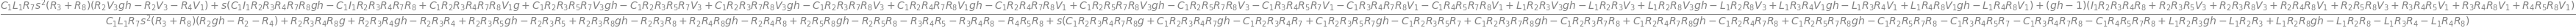

In [97]:
U_sym[v1].collect(s, factor, exact=False)

In [98]:
temp = f'$v_1(s) = {U_sym[v1].collect(s, factor, exact=False)}$'

temp = temp.replace('**','^').replace('*',' ')

# Apply subscripts to most variables, some manual editing will be required.
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
Typst_string = re.sub(pattern, replacement, temp) + ' <ex4_v1_node_equ>'
Typst_string

'$v_1(s) = (C_1 L_1 R_7 s^2 (R_3 + R_8) (R_2 V_3 g h - R_2 V_3 - R_4 V_1) + s (C_1 I_1 R_2 R_3 R_4 R_7 R_8 g h - C_1 I_1 R_2 R_3 R_4 R_7 R_8 + C_1 R_2 R_3 R_4 R_7 R_8 V_1 g + C_1 R_2 R_3 R_5 R_7 V_3 g h - C_1 R_2 R_3 R_5 R_7 V_3 + C_1 R_2 R_3 R_7 R_8 V_3 g h - C_1 R_2 R_3 R_7 R_8 V_3 + C_1 R_2 R_4 R_7 R_8 V_1 g h - C_1 R_2 R_4 R_7 R_8 V_1 + C_1 R_2 R_5 R_7 R_8 V_3 g h - C_1 R_2 R_5 R_7 R_8 V_3 - C_1 R_3 R_4 R_5 R_7 V_1 - C_1 R_3 R_4 R_7 R_8 V_1 - C_1 R_4 R_5 R_7 R_8 V_1 + L_1 R_2 R_3 V_3 g h - L_1 R_2 R_3 V_3 + L_1 R_2 R_8 V_3 g h - L_1 R_2 R_8 V_3 + L_1 R_3 R_4 V_1 g h - L_1 R_3 R_4 V_1 + L_1 R_4 R_8 V_1 g h - L_1 R_4 R_8 V_1) + (g h - 1) (I_1 R_2 R_3 R_4 R_8 + R_2 R_3 R_5 V_3 + R_2 R_3 R_8 V_3 + R_2 R_4 R_8 V_1 + R_2 R_5 R_8 V_3 + R_3 R_4 R_5 V_1 + R_3 R_4 R_8 V_1 + R_4 R_5 R_8 V_1))/(C_1 L_1 R_7 s^2 (R_3 + R_8) (R_2 g h - R_2 - R_4) + R_2 R_3 R_4 R_8 g + R_2 R_3 R_4 g h - R_2 R_3 R_4 + R_2 R_3 R_5 g h - R_2 R_3 R_5 + R_2 R_3 R_8 g h - R_2 R_3 R_8 + R_2 R_4 R_8 g h - R_2 R_4 R_8 + R_

Manually break equation into lengths of about 90 characters per long line with `\`. Fix any problems and copy paste into Typst.

Nevertheless, the solution for node voltage $v_1$ is shown below for illustration purposes. The expression for $v_1$ is of the form:

- could be useful if wanting to know the response as the value of one compent is varied, sort of a sensitivity analysis.

Doesn't really work since each frequency need to be evaluated.

In [99]:
element_values = SymMNA.get_part_values(network_df)

In [100]:
str(element_values)

'{V1: 10.0, V2: 0.0, V3: 3.0, I1: 3.0, g: 1.0, h: 3.0, C1: 0.1, L1: 4.0, R1: 5.0, R2: 3.0, R3: 9.0, R5: 1.0, R7: 7.0, R8: 2.0, R4: 2.0}'

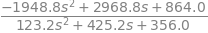

In [101]:
U_sym[v6].subs(element_values)

removing C1 from the list.

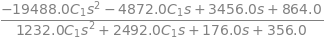

In [102]:
U_sym[v6].subs({V1: 10.0, V2: 0.0, V3: 3.0, I1: 3.0, g: 1.0, h: 3.0, L1: 4.0, R1: 5.0, R2: 3.0, R3: 9.0, R5: 1.0, R7: 7.0, R8: 2.0, R4: 2.0})

- could plot frequency vs. C1 values. But this could also be done with LTSpice.
- could find $\omega_n$, Q and $\zeta$ versus C1, since it is a 2nd order equation.

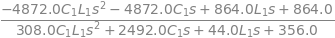

In [103]:
U_sym[v6].subs({V1: 10.0, V2: 0.0, V3: 3.0, I1: 3.0, g: 1.0, h: 3.0, R1: 5.0, R2: 3.0, R3: 9.0, R5: 1.0, R7: 7.0, R8: 2.0, R4: 2.0})

#### Analysis with $I_1=3$ at 0 Hz and $V_1=V_3=0$
The solution to the network equations at $\omega=0$ is called the DC Operating Point solution and is the steady-state direct current (DC) voltage and current conditions of a circuit when no input AC signal is applied. In the netlist $V_1$ is set to zero. Get the element values from the network dataframe.

In [104]:
element_values = SymMNA.get_part_values(network_df)

Set the value of $V_1$ and $V_3$to zero.

In [105]:
element_values[V1] = 0
element_values[V3] = 0

Substitute the numerical values into the equations.

In [106]:
# substitute numerical values
NE_dc = NE_sym.subs(element_values)

The circuit's node voltages and unknown currents can be solved for at individual frequencies. In the code cell below, a frequency of $s=j \omega = 0$ is used to evaluate the equations.

In [107]:
omega = 0 #frequency = DC
NE_dc = NE_dc.subs({s:1j*omega})

U_dc = solve(NE_dc,X)

table_header = ['unknown', 'Op Point','Units']
table_row = []

for name, value in U_dc.items():
    if str(name)[0] == 'v':
        table_row.append([str(name),float(value),'volts'])
    if str(name)[0] == 'I':
        table_row.append([str(name),float(value),'amps'])

print(tabulate(table_row, headers=table_header,colalign = ('left','decimal','left'),tablefmt="simple",floatfmt=('s','.6f','s')))

unknown      Op Point  Units
---------  ----------  -------
v1           1.820225  volts
v2           1.820225  volts
v3          -2.730337  volts
v4           1.820225  volts
v5           1.820225  volts
v6          -0.606742  volts
v7           2.730337  volts
v8          -0.606742  volts
v9           0.000000  volts
I_V1        -0.033708  amps
I_V2         0.910112  amps
I_V3         0.910112  amps
I_H         -0.303371  amps
I_L1        -0.606742  amps


The results above agree with those obtained from LTSpice.

```
       --- Operating Point ---

V(6):	 -0.606742	 voltage
V(1):	 1.82022	 voltage
V(3):	 -2.73034	 voltage
V(4):	 1.82022	 voltage
V(7):	 2.73034	 voltage
V(5):	 1.82022	 voltage
V(8):	 -0.606742	 voltage
V(2):	 1.82022	 voltage
V(9):	 0	 voltage
I(C1):	 0	 device_current
I(H):	 -0.303371	 device_current
I(L1):	 -0.606742	 device_current
I(I1):	 3	 device_current
I(R1):	 0.910112	 device_current
I(R2):	 -0.303371	 device_current
I(R3):	 -0.269663	 device_current
I(R5):	 -0.606742	 device_current
I(R7):	 0	 device_current
I(R8):	 1.21348	 device_current
I(R4):	 0.910112	 device_current
I(G):	 -0.910112	 device_current
I(V1):	 -0.0337079	 device_current
I(V2):	 0.910112	 device_current
I(V3):	 0.910112	 device_current


```

Code to generate formatted text for Typst for a table

In [108]:
typst_table_string = '#figure(\n    table(\n        columns: 3,\n        stroke: none,\n        table.header[unknown][Op Point][Units],\n'

for row in table_row:
    typst_table_string += f'        [${row[0]}$],[{row[1]:,.6f}],[{row[2]}],\n'

typst_table_string += '    ),\n    caption: [Operating point results],\n) <ex4_DC_results_table>\n'
print(typst_table_string)

#figure(
    table(
        columns: 3,
        stroke: none,
        table.header[unknown][Op Point][Units],
        [$v1$],[1.820225],[volts],
        [$v2$],[1.820225],[volts],
        [$v3$],[-2.730337],[volts],
        [$v4$],[1.820225],[volts],
        [$v5$],[1.820225],[volts],
        [$v6$],[-0.606742],[volts],
        [$v7$],[2.730337],[volts],
        [$v8$],[-0.606742],[volts],
        [$v9$],[0.000000],[volts],
        [$I_V1$],[-0.033708],[amps],
        [$I_V2$],[0.910112],[amps],
        [$I_V3$],[0.910112],[amps],
        [$I_H$],[-0.303371],[amps],
        [$I_L1$],[-0.606742],[amps],
    ),
    caption: [Operating point results],
) <ex4_DC_results_table>



#### Analysis with $V_1=10 \angle 0$ at 1 Hz and $I_1=V_3=0$
A frequency of $\omega=1$ was arbituarily chosen for the analysis. The component values are reloaded from the network dataframe with the following code.

Voltage is souce is rms. need to research this.

Typical phase notation used in text books: $V_1 = 10 \angle 0$ at 1 Hz.


In [109]:
element_values = SymMNA.get_part_values(network_df)

The DC current source $I_1$ is set to zero.

In [110]:
element_values[I1] = 0
element_values[V3] = 0

The numerical values are substituted into the network equations.

In [111]:
# substitute numerical values
NE_w1 = NE_sym.subs(element_values)

The circuit's node voltages and unknown currents can be solved for at individual frequencies. In the code cell below, a frequency of 1 radian per second is used to evaluate the network equations.

In [112]:
freq = 1
omega = freq*2*np.pi
NE_w1 = NE_w1.subs({s:1j*omega})

U_w1 = solve(NE_w1,X)

table_header = ['unknown', 'mag','phase, deg', 'units']
table_row = []

for name, value in U_w1.items():
    if str(name)[0] == 'v':
        table_row.append([str(name),float(abs(value)),float(arg(value)*180/np.pi),'volts'])
    if str(name)[0] == 'I':
        table_row.append([str(name),float(abs(value)),float(arg(value)*180/np.pi),'amps'])

print(tabulate(table_row, headers=table_header,colalign = ('left','decimal','decimal','left'),tablefmt="simple",floatfmt=('5s','.6f','.6f','s')))

unknown          mag    phase, deg  units
---------  ---------  ------------  -------
v1          5.617071   -120.248958  volts
v2          5.617071   -120.248958  volts
v3         30.752842     24.357027  volts
v4         14.192514   -150.381961  volts
v5         13.716574   -159.282973  volts
v6         18.067855   -140.596720  volts
v7         21.288770   -150.381961  volts
v8          0.718329    131.681805  volts
v9          0.000000    nan         volts
I_V1        2.408175     74.097108  amps
I_V2        7.096257   -150.381961  amps
I_V3        2.808536   -120.248958  amps
I_H         2.674393     44.956800  amps
I_L1        0.718329    131.681805  amps


The results shown above agree with those obtained from LTSpice.

```
       --- AC Analysis ---

frequency:	1	Hz
V(6):	mag:    18.0679 phase:   -140.597° 	voltage
V(1):	mag:    5.61707 phase:   -120.249° 	voltage
V(3):	mag:    30.7528 phase:     24.357° 	voltage
V(4):	mag:    14.1925 phase:   -150.382° 	voltage
V(7):	mag:    21.2888 phase:   -150.382° 	voltage
V(5):	mag:    13.7166 phase:   -159.283° 	voltage
V(8):	mag:   0.718329 phase:    131.682° 	voltage
V(2):	mag:    5.61707 phase:   -120.249° 	voltage
V(9):	mag:          0 phase:          0° 	voltage
I(C1):	mag:    1.39302 phase:    12.8092° 	device_current
I(H):	mag:    2.67439 phase:    44.9568° 	device_current
I(L1):	mag:   0.718329 phase:    131.682° 	device_current
I(I1):	mag:          0 phase:          0° 	device_current
I(R1):	mag:    7.09626 phase:   -150.382° 	device_current
I(R2):	mag:    2.67439 phase:    44.9568° 	device_current
I(R3):	mag:   0.745863 phase:   -99.7027° 	device_current
I(R5):	mag:   0.718329 phase:    131.682° 	device_current
I(R7):	mag:    1.39302 phase:    12.8092° 	device_current
I(R8):	mag:    6.47472 phase:    30.7283° 	device_current
I(R4):	mag:    2.80854 phase:   -120.249° 	device_current
I(G):	mag:    7.09626 phase:     29.618° 	device_current
I(V1):	mag:    2.40817 phase:    74.0971° 	device_current
I(V2):	mag:    7.09626 phase:   -150.382° 	device_current
I(V3):	mag:    2.80854 phase:   -120.249° 	device_current
```

In [113]:
typst_table_string = '#figure(\n    table(\n        columns: 3,\n        stroke: none,\n        table.header[unknown][Magnitude][Phase],\n'

for row in table_row:
    typst_table_string += f'        [${row[0]}$],[{row[1]:,.6f}],[{row[2]:,.6f}],\n'

typst_table_string += '    ),\n    caption: [AC analysis results for $V_1$ at $omega_1$],\n) <ex4_ac_w1_results_table>\n'
print(typst_table_string)

#figure(
    table(
        columns: 3,
        stroke: none,
        table.header[unknown][Magnitude][Phase],
        [$v1$],[5.617071],[-120.248958],
        [$v2$],[5.617071],[-120.248958],
        [$v3$],[30.752842],[24.357027],
        [$v4$],[14.192514],[-150.381961],
        [$v5$],[13.716574],[-159.282973],
        [$v6$],[18.067855],[-140.596720],
        [$v7$],[21.288770],[-150.381961],
        [$v8$],[0.718329],[131.681805],
        [$v9$],[0.000000],[nan],
        [$I_V1$],[2.408175],[74.097108],
        [$I_V2$],[7.096257],[-150.381961],
        [$I_V3$],[2.808536],[-120.248958],
        [$I_H$],[2.674393],[44.956800],
        [$I_L1$],[0.718329],[131.681805],
    ),
    caption: [AC analysis results for $V_1$ at $omega_1$],
) <ex4_ac_w1_results_table>



#### AC Analysis with $V_3=3 \angle 45$ at 5 Hz and $I_1=V_1=0$
A frequency of 5 Hz was arbituarily chosen for the analysis. The component values are reloaded from the network dataframe with the following code.

Typical phase notation used in text books: $V_3 = 3 \angle 45$ at 5 Hz.

In [114]:
element_values = SymMNA.get_part_values(network_df)

In [115]:
element_values[V3]

In [116]:
element_values[V3] = polar2rec(element_values[V3], 45, units='deg')
element_values[V3]

(2.121320343559643+2.1213203435596424j)

The DC current source $I_1$ is set to zero.

In [117]:
element_values[I1] = 0
element_values[V1] = 0

The numerical values are substituted into the network equations.

In [118]:
# substitute numerical values
NE_w2 = NE_sym.subs(element_values)

The circuit's node voltages and unknown currents can be solved for at individual frequencies. In the code cell below, a frequency of 1 radian per second is used to evaluate the network equations.

In [119]:
freq = 5
omega = freq*2*np.pi
NE_w2 = NE_w2.subs({s:1j*omega})

U_w2 = solve(NE_w2,X)

table_header = ['unknown', 'mag','phase, deg', 'units']
table_row = []

for name, value in U_w2.items():
    if str(name)[0] == 'v':
        table_row.append([str(name),float(abs(value)),float(arg(value)*180/np.pi),'volts'])
    if str(name)[0] == 'I':
        table_row.append([str(name),float(abs(value)),float(arg(value)*180/np.pi),'amps'])

print(tabulate(table_row, headers=table_header,colalign = ('left','decimal','decimal','left'),tablefmt="simple",floatfmt=('5s','.6f','.6f','s')))

unknown         mag    phase, deg  units
---------  --------  ------------  -------
v1         4.491690     47.482066  volts
v2         4.491690     47.482066  volts
v3         6.737535   -132.517934  volts
v4         4.491690     47.482066  volts
v5         4.491690     47.482066  volts
v6         8.165170     48.227992  volts
v7         6.737535     47.482066  volts
v8         0.064974    -41.316073  volts
v9         3.000000     45.000000  volts
I_V1       1.156763   -131.932916  amps
I_V2       2.245845     47.482066  amps
I_V3       0.750070     52.450404  amps
I_H        0.748615   -132.517934  amps
I_L1       0.064974    -41.316073  amps


The results shown above agree with those obtained from LTSpice.

```
       --- AC Analysis ---
frequency:	5	Hz
V(6):	mag:    8.16517 phase:     48.228° 	voltage
V(1):	mag:    4.49169 phase:    47.4821° 	voltage
V(3):	mag:    6.73753 phase:   -132.518° 	voltage
V(4):	mag:    4.49169 phase:    47.4821° 	voltage
V(7):	mag:    6.73753 phase:    47.4821° 	voltage
V(5):	mag:    4.49169 phase:    47.4821° 	voltage
V(8):	mag:  0.0649743 phase:   -41.3161° 	voltage
V(2):	mag:    4.49169 phase:    47.4821° 	voltage
V(9):	mag:          3 phase:         45° 	voltage
I(C1):	mag:          0 phase:          0° 	device_current
I(H):	mag:   0.748615 phase:   -132.518° 	device_current
I(L1):	mag:  0.0649743 phase:   -41.3161° 	device_current
I(I1):	mag:          0 phase:          0° 	device_current
I(R1):	mag:    2.24584 phase:    47.4821° 	device_current
I(R2):	mag:   0.748615 phase:   -132.518° 	device_current
I(R3):	mag:   0.408259 phase:    49.1399° 	device_current
I(R5):	mag:  0.0649743 phase:   -41.3161° 	device_current
I(R7):	mag:          0 phase:          0° 	device_current
I(R8):	mag:    1.83716 phase:    -130.86° 	device_current
I(R4):	mag:    0.75007 phase:    52.4504° 	device_current
I(G):	mag:    2.24584 phase:   -132.518° 	device_current
I(V1):	mag:    1.15676 phase:   -131.933° 	device_current
I(V2):	mag:    2.24584 phase:    47.4821° 	device_current
I(V3):	mag:    0.75007 phase:    52.4504° 	device_current
```

In [120]:
typst_table_string = '#figure(\n    table(\n        columns: 3,\n        stroke: none,\n        table.header[unknown][Magnitude][Phase],\n'

for row in table_row:
    typst_table_string += f'        [${row[0]}$],[{row[1]:,.6f}],[{row[2]:,.6f}],\n'

typst_table_string += '    ),\n    caption: [AC analysis results for $V_1$ at $omega_2$],\n) <ex4_ac_w2_results_table>\n'
print(typst_table_string)

#figure(
    table(
        columns: 3,
        stroke: none,
        table.header[unknown][Magnitude][Phase],
        [$v1$],[4.491690],[47.482066],
        [$v2$],[4.491690],[47.482066],
        [$v3$],[6.737535],[-132.517934],
        [$v4$],[4.491690],[47.482066],
        [$v5$],[4.491690],[47.482066],
        [$v6$],[8.165170],[48.227992],
        [$v7$],[6.737535],[47.482066],
        [$v8$],[0.064974],[-41.316073],
        [$v9$],[3.000000],[45.000000],
        [$I_V1$],[1.156763],[-131.932916],
        [$I_V2$],[2.245845],[47.482066],
        [$I_V3$],[0.750070],[52.450404],
        [$I_H$],[0.748615],[-132.517934],
        [$I_L1$],[0.064974],[-41.316073],
    ),
    caption: [AC analysis results for $V_1$ at $omega_2$],
) <ex4_ac_w2_results_table>



In [121]:
U_total = U_w2.copy()
for i in U_dc.keys():
    U_total[i] = U_dc[i] + U_w1[i] + U_w2[i]
U_total

In [122]:
table_header = ['unknown', 'mag','phase, deg', 'units']
table_row = []

for name, value in U_total.items():
    if str(name)[0] == 'v':
        table_row.append([str(name),float(abs(value)),float(arg(value)*180/np.pi),'volts'])
    if str(name)[0] == 'I':
        table_row.append([str(name),float(abs(value)),float(arg(value)*180/np.pi),'amps'])

print(tabulate(table_row, headers=table_header,colalign = ('left','decimal','decimal','left'),tablefmt="simple",floatfmt=('5s','.6f','.6f','s')))

unknown          mag    phase, deg  units
---------  ---------  ------------  -------
v1          2.545950    -37.265774  volts
v2          2.545950    -37.265774  volts
v3         22.121635     20.416958  volts
v4          8.348699   -153.666141  volts
v5          8.121498   -169.057841  volts
v6         10.595512   -149.488750  volts
v7         12.523049   -153.666141  volts
v8          1.147234    154.517174  volts
v9          3.000000     45.000000  volts
I_V1        1.462851     95.762104  amps
I_V2        4.174350   -153.666141  amps
I_V3        1.832081    -91.488223  amps
I_H         1.721409     51.004780  amps
I_L1        1.147234    154.517174  amps


In [123]:
typst_table_string = '#figure(\n    table(\n        columns: 3,\n        stroke: none,\n        table.header[unknown][Magnitude][Phase],\n'

for row in table_row:
    typst_table_string += f'        [${row[0]}$],[{row[1]:,.6f}],[{row[2]:,.6f}],\n'

typst_table_string += '    ),\n    caption: [AC analysis results for $V_1$ at DC, $omega_1$ and $omega_2$],\n) <ex4_total_results_table>\n'
print(typst_table_string)

#figure(
    table(
        columns: 3,
        stroke: none,
        table.header[unknown][Magnitude][Phase],
        [$v1$],[2.545950],[-37.265774],
        [$v2$],[2.545950],[-37.265774],
        [$v3$],[22.121635],[20.416958],
        [$v4$],[8.348699],[-153.666141],
        [$v5$],[8.121498],[-169.057841],
        [$v6$],[10.595512],[-149.488750],
        [$v7$],[12.523049],[-153.666141],
        [$v8$],[1.147234],[154.517174],
        [$v9$],[3.000000],[45.000000],
        [$I_V1$],[1.462851],[95.762104],
        [$I_V2$],[4.174350],[-153.666141],
        [$I_V3$],[1.832081],[-91.488223],
        [$I_H$],[1.721409],[51.004780],
        [$I_L1$],[1.147234],[154.517174],
    ),
    caption: [AC analysis results for $V_1$ at DC, $omega_1$ and $omega_2$],
) <ex4_total_results_table>



## Discussion and Conclusion
This paper serves as a practical procedure for performing symbolic circuit analysis using the Python programming language and its associated scientific libraries, such as SymPy and NumPy. The primary goal is to provide a systematic and computationally efficient procedure for analyzing linear electric circuits, utilizing JupyterLab Notebooks as adaptable templates. MNA is an essential extension of standard nodal analysis that allows all types of circuit elements (including voltage sources, inductors, and dependent sources) to be incorporated into a single, unified matrix formulation.

Key Concepts:

- Symbolic Analysis: This technique calculates a circuit's behavior (e.g., gain, impedance) with components and frequency represented by symbols instead of numerical values. This provides qualitative insight into the circuit's operation, aids in design optimization, and yields exact analytical solutions that numerical simulators (like SPICE) cannot.
- Modified Nodal Analysis (MNA): The procedure leverages MNA to formulate the circuit problem as a system of simultaneous linear equations, $\mathbf{G} \cdot \mathbf{V} = \mathbf{I}$, which is then solved using Linear Algebra techniques (matrix inversion) implemented in Python.
- Advanced Concepts (The s-Domain): The procedure utilaizes Laplace Transformed Circuit Models, which convert time-domain differential equations into simpler algebraic equations in the s-domain (complex frequency domain). This is crucial for analyzing circuits with energy storage elements (capacitors and inductors) and determining their transient and transfer functions.

## Python Code Availability
The Python code and computation results presented in this paper are contained in a JupyterLab notebook which is hosted on GitHub at https://github.com/Tiburonboy/EE_jupyter_notebooks/tree/main/Circuit_Analysis_with_Python.